In [1]:
%load_ext autoreload
%autoreload 2

### 1. 모듈 임포트

In [5]:
import torch
import numpy as np
import os
import glob
# 1. 모듈 임포트
import taichi as ti
from modules.config import config
from modules.taichi_fluid_solver  import TaichiFluidSolver
from modules.config import config
from modules.dataset import SDFDataset
from modules.sdf_generator import SDFGenerator
from modules.particle_sampler import sample_particles_poisson
from modules.sdf_network import FeatureConstruction
from modules.visualizer import visualize_simulation, visualize_particles_and_features, visualize_feature_grid

In [35]:
# ==========================================
# Setup: Config & 디바이스 초기화
# ==========================================
print(f"⚙️ Config 설정: Domain Size={config.domain_size}, Resolution={config.resolution}")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"⚡ 디바이스 초기화: {device}")

# 시각화나 솔버를 초기화하기 전에 반드시 GPU(혹은 CPU) 런타임을 먼저 켭니다.
ti.init(arch=ti.gpu)

⚙️ Config 설정: Domain Size=2.0, Resolution=128
⚡ 디바이스 초기화: cuda
[Taichi] Starting on arch=cuda


In [36]:
def load_particles_from_txt(txt_path, device='cpu'):
    """
    x y z 형태로 저장된 파티클 .txt 파일을 읽어 PyTorch 텐서로 반환합니다.
    (축 방향 수정 및 -1~1 스케일 정규화 포함)
    """
    import os
    import numpy as np
    import torch

    if not os.path.exists(txt_path):
        raise FileNotFoundError(f"❌ 파일을 찾을 수 없습니다: {txt_path}")
        
    print(f"📄 파티클 파일 로드 중: {txt_path}")
    
    valid_particles = []
    error_count = 0
    
    with open(txt_path, 'r') as f:
        for line_idx, line in enumerate(f):
            line = line.strip()
            if not line:
                continue
                
            parts = line.split()
            if len(parts) == 3:
                try:
                    # 1. 텍스트에서 숫자 추출
                    x = float(parts[0])
                    y = float(parts[1])
                    z = float(parts[2])
                    
                    valid_particles.append([x, y, z])
                    
                except ValueError:
                    error_count += 1
            else:
                if error_count == 0: 
                    print(f"  ⚠️ [형식 무시됨] Line {line_idx+1}: '{line}'")
                error_count += 1

    if not valid_particles:
        raise ValueError("❌ 유효한 파티클(x y z) 데이터를 하나도 찾지 못했습니다.")
        
    particles_np = np.array(valid_particles, dtype=np.float32)
    
    # =======================================================
    # 🚨 [해결책 2] 0~1 공간을 -1~1 공간으로 뻥튀기 (Scale Remapping)
    # 공식: New_Value = (Old_Value * 2.0) - 1.0
    # 이렇게 하면 0.0은 -1.0이 되고, 0.5는 0.0(중앙)이 되며, 1.0은 1.0이 됩니다.
    # =======================================================
    print(f"🔍 변환 전 파티클 범위: Min {particles_np.min():.3f} ~ Max {particles_np.max():.3f}")
    
    particles_np = ((particles_np) - 0.5)*1.2
    
    print(f"🚀 변환 후 파티클 범위: Min {particles_np.min():.3f} ~ Max {particles_np.max():.3f} (그리드 최적화 완료!)")
    # =======================================================

    print(f"✅ 로드 완료! 정상 파티클: {particles_np.shape[0]:,}개 (건너뛴 줄: {error_count}개)")
    
    # GPU 텐서로 변환하여 반환
    particles_tensor = torch.tensor(particles_np, dtype=torch.float32, device=device)
    return particles_tensor

## 2. 데이터셋 생성

### 2.1 랜덤 도형을 통해 sdf Poisson Disk 샘플링 파티클 데이터셋 생성

In [ ]:
# sdf, 파티클 생성 함수.
SDFDataset.generate_dataset(
    output_dir="dataset6",
    dataset_size=200,
    start_index=0,
    save_sdf=True,
    save_particles=True,
    save_mc=True,        # mc는 데이터로더에서도 계산 가능. False해도 됨.
    config=config,
    device=device,
    cleanup_old_files = True
)

🗑️ Removed old dataset file: dataset6\mc_grid_000.npy
🗑️ Removed old dataset file: dataset6\mc_grid_001.npy
🗑️ Removed old dataset file: dataset6\mc_grid_002.npy
🗑️ Removed old dataset file: dataset6\mc_grid_003.npy
🗑️ Removed old dataset file: dataset6\mc_grid_004.npy
🗑️ Removed old dataset file: dataset6\mc_grid_005.npy
🗑️ Removed old dataset file: dataset6\mc_grid_006.npy
🗑️ Removed old dataset file: dataset6\mc_grid_007.npy
🗑️ Removed old dataset file: dataset6\mc_grid_008.npy
🗑️ Removed old dataset file: dataset6\mc_grid_009.npy
🗑️ Removed old dataset file: dataset6\mc_grid_010.npy
🗑️ Removed old dataset file: dataset6\mc_grid_011.npy
🗑️ Removed old dataset file: dataset6\mc_grid_012.npy
🗑️ Removed old dataset file: dataset6\mc_grid_013.npy
🗑️ Removed old dataset file: dataset6\mc_grid_014.npy
🗑️ Removed old dataset file: dataset6\mc_grid_015.npy
🗑️ Removed old dataset file: dataset6\mc_grid_016.npy
🗑️ Removed old dataset file: dataset6\mc_grid_017.npy
🗑️ Removed old dataset file:

KeyboardInterrupt: 

### 2.2 시뮬레이션 뷰어 및 시뮬레이션 데이터 셋 생성

In [7]:
# ==========================================
# 1. 모듈 임포트 및 Taichi 엔진 초기화
# ==========================================
import taichi as ti
from modules.config import config
from modules.taichi_fluid_solver  import TaichiFluidSolver

# 시각화나 솔버를 초기화하기 전에 반드시 GPU(혹은 CPU) 런타임을 먼저 켭니다.
ti.init(arch=ti.gpu)


# (visualizer.py가 같은 경로에 있다면 바로 임포트, modules 폴더 안이라면 modules.visualizer로 임포트)
from modules.visualizer import run_realtime_visualizer 

# ==========================================
# 2. 유체 시뮬레이터 세팅
# ==========================================
res = config.resolution            # 실시간 테스트용 해상도
domain_size = config.domain_size

# 솔버 객체 생성 및 초기 물기둥(Dam Break) 배치
solver = TaichiFluidSolver(res=config.resolution, domain_size=config.domain_size, p_per_cell=1.0)
solver.setup_initial_fluid_block()

print(f"✅ 준비된 활성 파티클 수: {solver.get_active_particle_count():,}개")

# ==========================================
# 3. 실시간 3D 뷰어 구동!
# ==========================================
# 세팅이 끝난 솔버를 통째로 뷰어에 넘겨줍니다.
solver.run_taichi_viewer()

[Taichi] Starting on arch=cuda
✅ 준비된 활성 파티클 수: 156,832개

[초고속 튜닝 SPH 뷰어 구동]


In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# sdf, 파티클 생성 함수.
TaichiFluidSolver.generate_dataset(
    output_dir="dataset6",
    dataset_size=160,
    start_index=0,
    save_sdf=True,
    save_particles=True,
    save_mc=True,        # mc는 데이터로더에서도 계산 가능. False해도 됨.
    config=config,
    device=device,
    cleanup_old_files = False
)

self.R : 0.04365157071850156

🚀 Launching Optimized Fluid Simulator Pipeline...
   [Target Frames]: 160 | Resolution: 128^3

[1/160] Simulating Fluid State...
   ⏩ Pass saving (Physics updated)

[2/160] Simulating Fluid State...
   💾 [Frame 001] Extracting & Saving Data...
📊 공간 분석: 전체 2,097,152개 격자 중 유체 내부(음수) 격자는 162,068개 (7.73%) 입니다.
   ✅ Saved Frame 001: SDF, Particles, m_c Grid (Particles: 156,832)

[3/160] Simulating Fluid State...
   ⏩ Pass saving (Physics updated)

[4/160] Simulating Fluid State...
   ⏩ Pass saving (Physics updated)

[5/160] Simulating Fluid State...
   ⏩ Pass saving (Physics updated)

[6/160] Simulating Fluid State...
   💾 [Frame 005] Extracting & Saving Data...
📊 공간 분석: 전체 2,097,152개 격자 중 유체 내부(음수) 격자는 161,868개 (7.72%) 입니다.
   ✅ Saved Frame 005: SDF, Particles, m_c Grid (Particles: 156,832)

[7/160] Simulating Fluid State...
   ⏩ Pass saving (Physics updated)

[8/160] Simulating Fluid State...
   ⏩ Pass saving (Physics updated)

[9/160] Simulating Fluid State.

### 2.2 visualize dataset

📥 SDF 데이터 로드: dataset6/sdf_grid_100.npy (Shape: (128, 128, 128))
📥 m_c 데이터 로드: dataset6/mc_grid_100.npy (Shape: (129, 129, 129))

[1] 정답(Target) SDF 형상 시각화


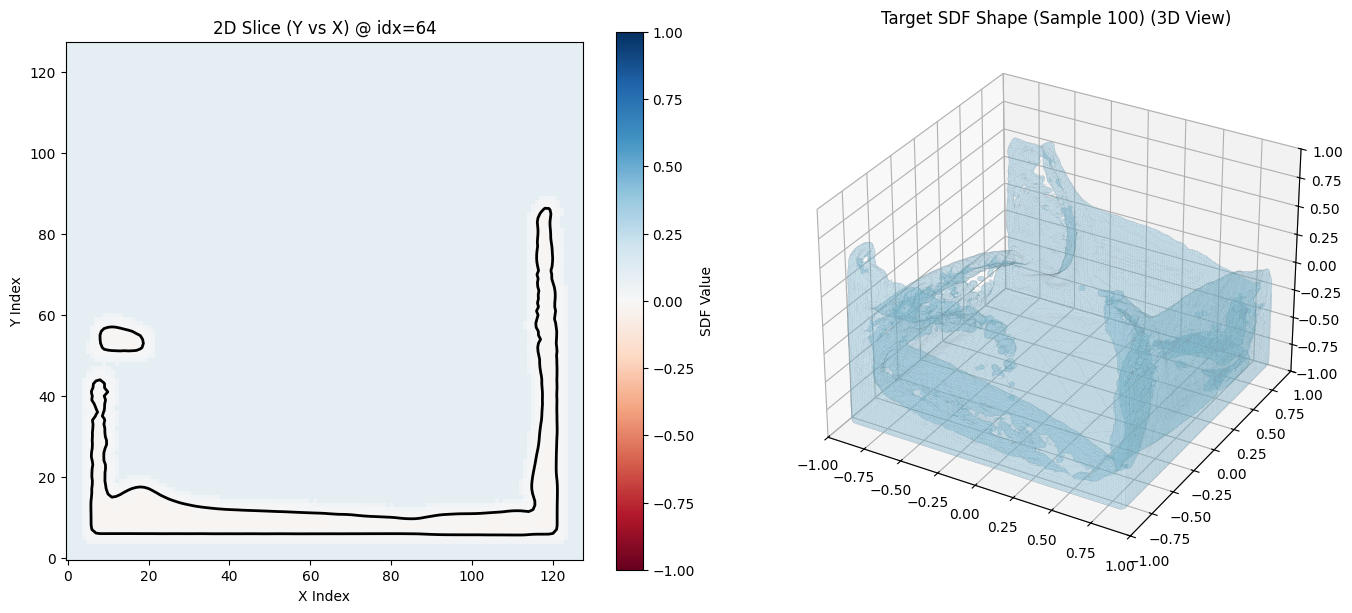


[2] 입력(Input) m_c 특징 공간 시각화
💡 grid_nodes가 생략되었습니다. (129, 129, 129) 해상도의 기본 공간 격자를 자동 생성합니다.


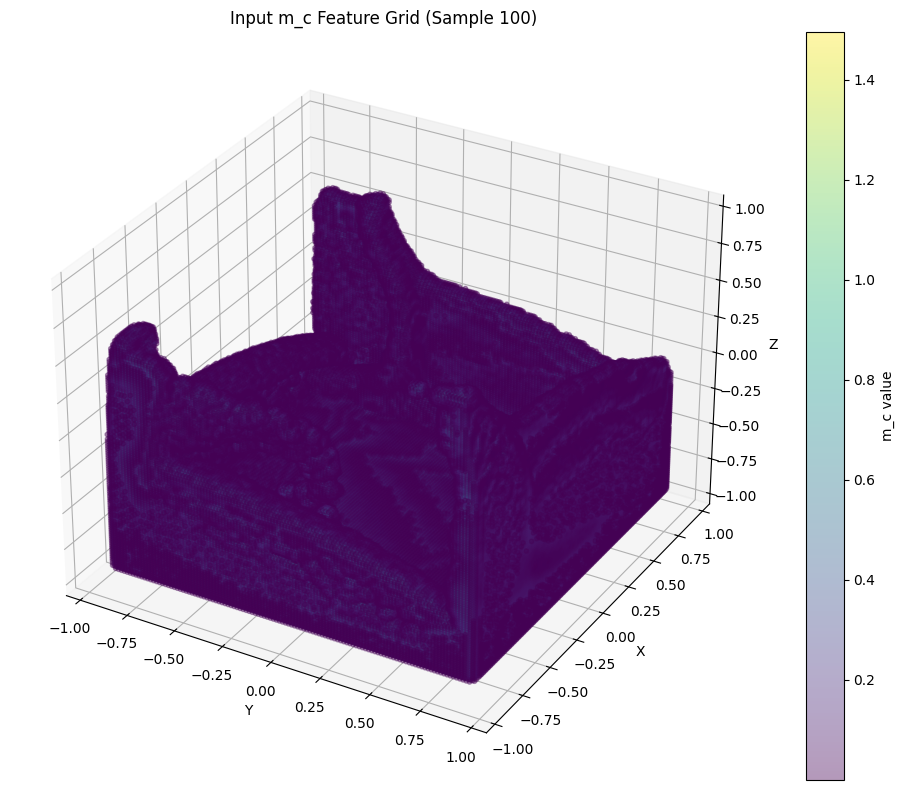

In [37]:
from modules.visualizer import visualize_simulation, visualize_feature_grid,visualize_particles_and_features

# 1. 확인할 데이터 인덱스 설정 (0 ~ 4)
sample_idx = 100
sdf_file = f"dataset6/sdf_grid_{sample_idx:03d}.npy"
mc_file = f"dataset6/mc_grid_{sample_idx:03d}.npy"

# 2. 데이터 로드 완료
sdf_grid = np.load(sdf_file)
mc_grid = np.load(mc_file)
print(f"📥 SDF 데이터 로드: {sdf_file} (Shape: {sdf_grid.shape})")
print(f"📥 m_c 데이터 로드: {mc_file} (Shape: {mc_grid.shape})")

# 3. [시각화 1] Target SDF (원본 3D 지오메트리 형태)
print("\n[1] 정답(Target) SDF 형상 시각화")
visualize_simulation(
    sdf_grid=sdf_grid, 
    domain_size=config.domain_size, 
    title=f"Target SDF Shape (Sample {sample_idx})"
)

# 4. [시각화 2] Input 3D CNN Features (파티클로부터 밀도 단위로 추출된 m_c 값)
print("\n[2] 입력(Input) m_c 특징 공간 시각화")

fig2 = visualize_feature_grid(
    m_c_grid=mc_grid,         # 앞서 파이프라인에서 나온 mc_grid 텐서 그대로 삽입
    # grid_nodes=grid_nodes,    # 앞서 파이프라인에서 나온 grid_nodes 텐서 그대로 삽입
    title=f"Input m_c Feature Grid (Sample {sample_idx})"
)

sdf to obj

In [38]:
from modules.visualizer import save_mesh_as_obj, draw_sdf_mesh, view_obj_interactive

# 1. 확인할 프레임 번호 및 기본 경로 설정
frame_number = 100  # 확인하고 싶은 프레임 번호 입력
dataset_dir = "dataset6"

# 앞서 데이터셋 생성 시 사용한 자릿수(03d)에 맞춰 파일명 지정
npy_path = os.path.join(dataset_dir, f"sdf_grid_{frame_number:03d}.npy")
obj_path = os.path.join(dataset_dir, f"frame_{frame_number:03d}.obj")

# 2. SDF 데이터 로드 및 처리
if not os.path.exists(npy_path):
    print(f"❌ 경고: 파일을 찾을 수 없습니다 ({npy_path})")
else:
    print(f"[{frame_number:03d} 프레임] SDF 데이터를 로드합니다...")
    sdf_grid = np.load(npy_path)

    # 3. visualizer.py의 함수를 호출하여 OBJ 파일로 추출 및 저장
    success = save_mesh_as_obj(sdf_grid, filename=obj_path, level=0.0)


[100 프레임] SDF 데이터를 로드합니다...
✅ 메쉬 저장 완료: dataset6\frame_100.obj (Vertices: 111227)


In [39]:
dataset_dir = "dataset6"
frame_number = 100  # 확인하고 싶은 프레임 번호 입력
obj_path = os.path.join(dataset_dir, f"frame_{frame_number:03d}.obj")

# 4. OBJ 파일이 성공적으로 저장되었다면 뷰어 실행
view_obj_interactive(filename=obj_path)

🖥️ 3D 뷰어 실행 중: dataset6\frame_100.obj ...
✅ 뷰어 종료됨.


⚙️ 공통 Grid Nodes 3D 좌표 복원 중...
self.R : 0.047244094488188976
📊 [PPC = 1] 시각화 준비 완료
💡 grid_nodes가 생략되었습니다. (128, 128, 128) 해상도의 기본 공간 격자를 자동 생성합니다.
self.R : 0.04399528387376535
📊 [PPC = 2] 시각화 준비 완료
💡 grid_nodes가 생략되었습니다. (128, 128, 128) 해상도의 기본 공간 격자를 자동 생성합니다.
self.R : 0.04241513817875015
📊 [PPC = 3] 시각화 준비 완료
💡 grid_nodes가 생략되었습니다. (128, 128, 128) 해상도의 기본 공간 격자를 자동 생성합니다.
self.R : 0.041416701180274594
📊 [PPC = 4] 시각화 준비 완료
💡 grid_nodes가 생략되었습니다. (128, 128, 128) 해상도의 기본 공간 격자를 자동 생성합니다.


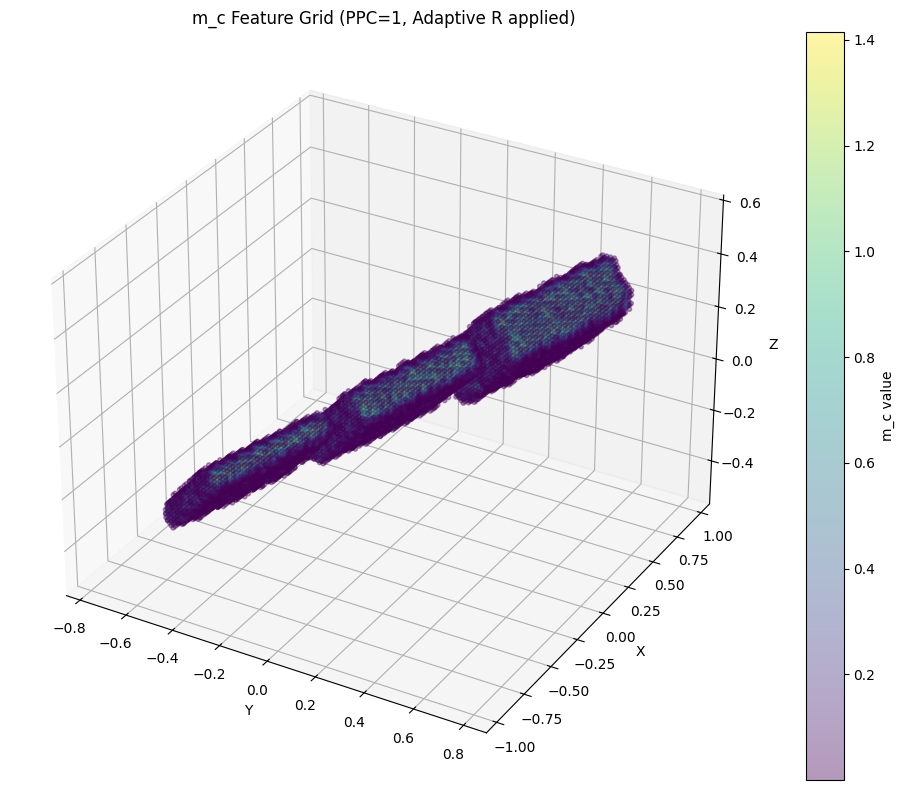

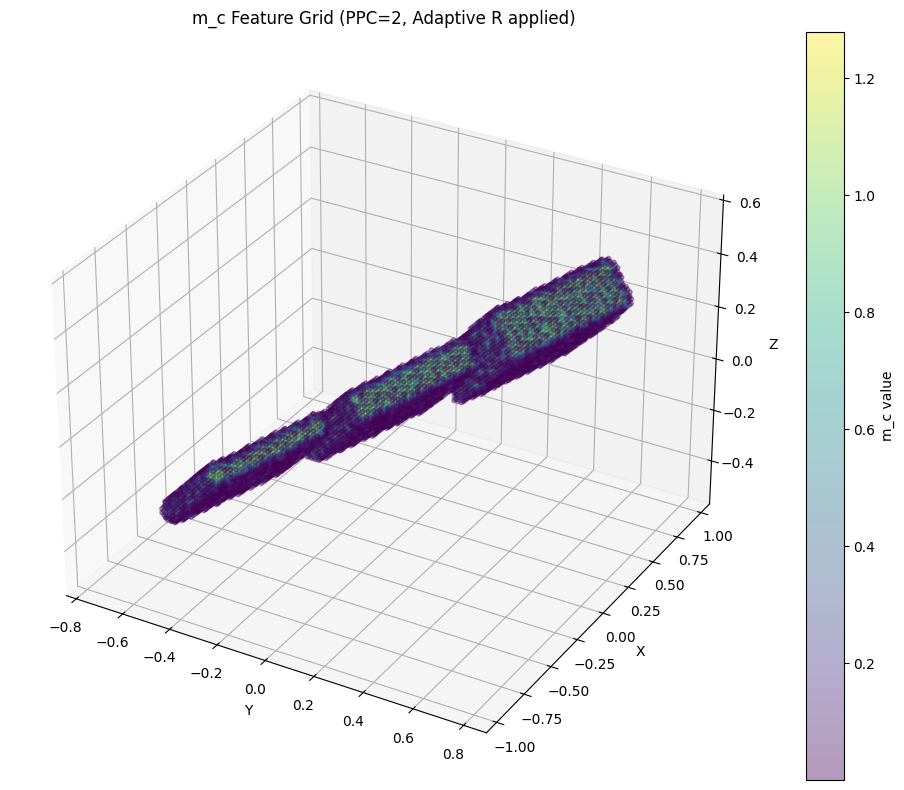

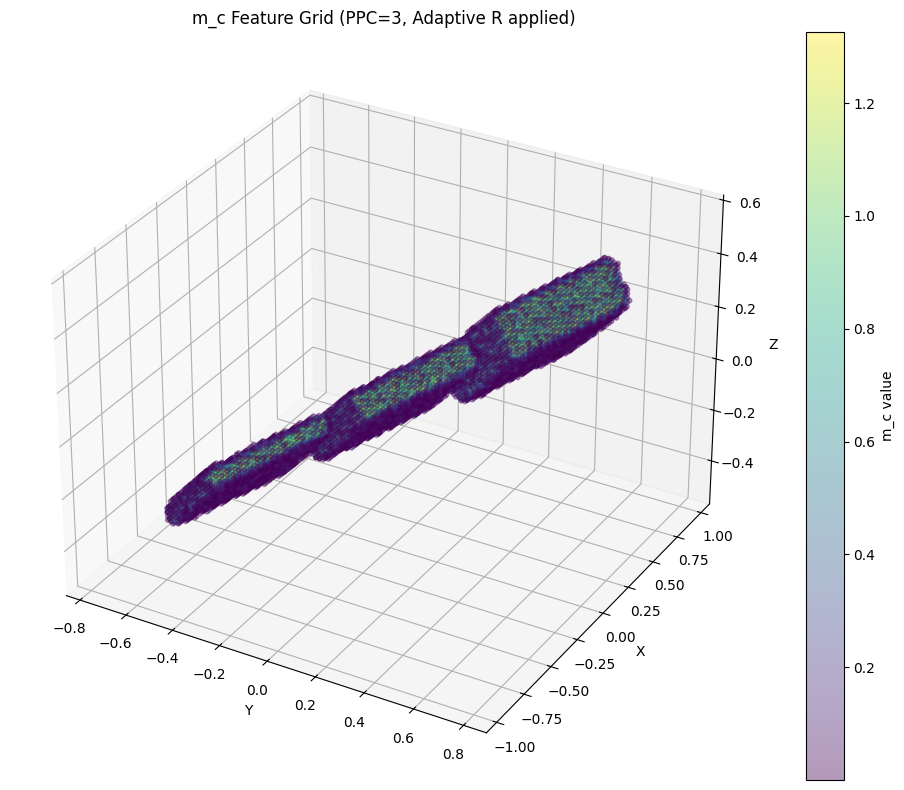

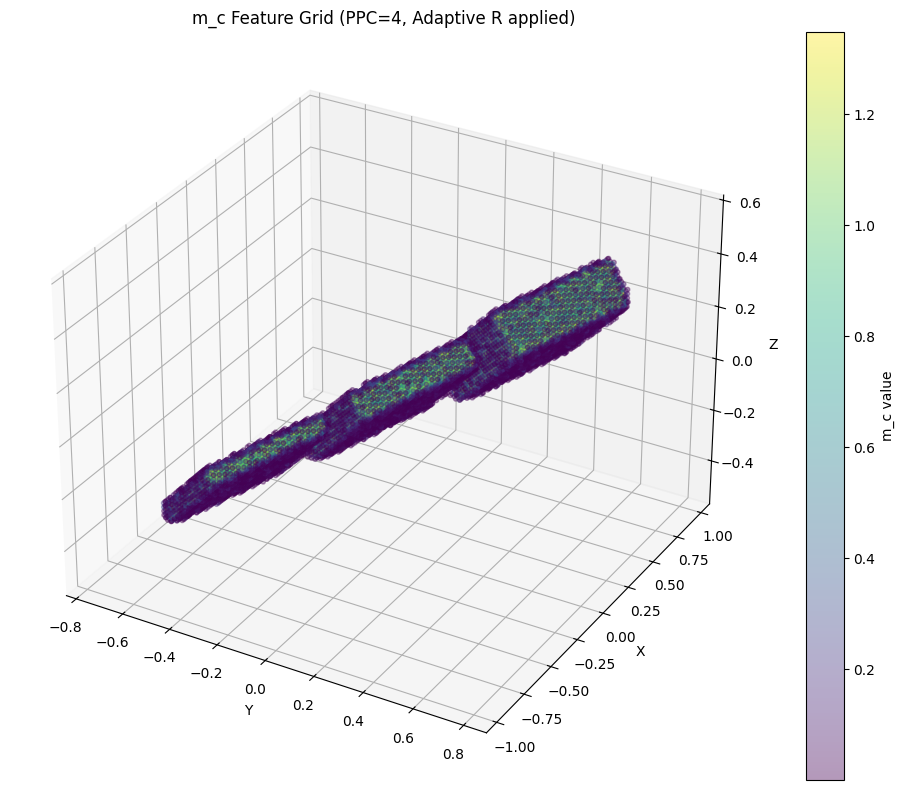

In [40]:
# ==========================================
# 1. 설정 및 공통 Grid Nodes 복원
# ==========================================
save_dir = "./dataset_ppc_test2"
ppc_list = [1, 2, 3, 4]

print("⚙️ 공통 Grid Nodes 3D 좌표 복원 중...")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


# ==========================================
# 2. 저장된 파일 로드 및 시각화
# ==========================================
for ppc in ppc_list:
    feature_constructor = FeatureConstruction(dx=config.dx, 
        ppc=ppc, device=device)
    # dx와 도메인 사이즈만 있으면 동일한 격자 좌표를 얻을 수 있습니다.
    grid_nodes_tensor, _ = feature_constructor.create_grid()
    grid_nodes_np = grid_nodes_tensor.cpu().numpy()
    mc_filename = os.path.join(save_dir, f"mc_grid_ppc{ppc}.npy")
    
    if not os.path.exists(mc_filename):
        print(f"❌ 파일을 찾을 수 없습니다: {mc_filename}")
        continue
        
    # .npy 파일에서 m_c 데이터 로드
    m_c_grid = np.load(mc_filename)
    
    print(f"📊 [PPC = {ppc}] 시각화 준비 완료")
    
    # 띄울 그래프(Figure) 생성
    fig = visualize_feature_grid(
        m_c_grid=m_c_grid,
        # grid_nodes=grid_nodes_np,
        title=f"m_c Feature Grid (PPC={ppc}, Adaptive R applied)"
    )

plt.show()

## 3. CNN Training& Inference

### 3.1 학습

디바이스/데이터로더 설정 셀

In [ ]:
# import time
# import torch.optim as optim
# from tqdm import tqdm

# from modules.dataset import SDFDataset, DataLoader
# from modules.sdf_network import SDFNetwork, PolynomialRegularizedSDFLoss, SDFReconstruction, FeatureConstruction
# from modules.config import config
# from modules.visualizer import visualize_simulation

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"⚡ 작동 디바이스: {device}")

# ==========================================
# 📦 1. 데이터 로드 (Narrow Band 적용)
# ==========================================
print("\n[데이터 로드 시작]")

train_dataset = SDFDataset(
    data_dirs=["dataset6"] ,   # 🚨 경로 확인 (dataset4)
    patch_size=8,
    in_memory=True, 
    use_narrow_band=True, 
    use_bg_sample=False,     
    bg_sample_ratio=0.10,
    max_samples=10000000
)

# 공통 학습 파라미터 세팅 (빠른 실험을 위해 데이터의 50%만 학습)
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True, num_workers=0)
max_batches = len(train_loader)

⚡ 작동 디바이스: cuda

[데이터 로드 시작]
💾 총 160쌍의 데이터를 메모리에 캐싱 중입니다...
✅ 캐싱 완료.
🔍 [초고속 필터링] 표면(|SDF| <= 0.0312) 샘플링 중...
✂️ [데이터 제한] 전체 47,656,841개 샘플 중 무작위 10,000,000개만 선택되었습니다.
✅ 샘플링 완료!
   - 표면(Narrow Band) 데이터: 47656841개 (100% 사용)
   - 최종 학습 데이터: 10000000개 (전체 중 3.0%)


훈련 반복문 셀

In [13]:
num_epochs = 3

In [14]:

# ==========================================
# 🧪 [실험 1] 다항식 정규화(Polynomial) + MSE 
# ==========================================
print("\n" + "="*55)
print(">> 🧪 [실험 1] 다항식 정규화(Poly) + MSE 모드 학습 시작")
print("="*55)

model_poly = SDFNetwork().to(device)
optimizer_poly = optim.Adam(model_poly.parameters(), lr=0.0002)
criterion_poly = PolynomialRegularizedSDFLoss(lambda_reg=1.0, use_poly_loss=True).to(device)

start_time = time.time()
model_poly.train_step(
    train_loader=train_loader,
    optimizer=optimizer_poly,
    criterion=criterion_poly,
    device=device,
    num_epochs=num_epochs,
    max_batches_per_epoch=max_batches
)
print(f"✅ 실험 1 학습 완료! (소요 시간: {time.time() - start_time:.1f}초)")





>> 🧪 [실험 1] 다항식 정규화(Poly) + MSE 모드 학습 시작


Epoch [01/03]: 100%|██████████| 39063/39063 [13:40<00:00, 47.61it/s, loss=0.00003]


✅ Epoch 1 완료! 평균 Loss: 0.000295



Epoch [02/03]: 100%|██████████| 39063/39063 [13:40<00:00, 47.61it/s, loss=0.00005]


✅ Epoch 2 완료! 평균 Loss: 0.000041



Epoch [03/03]: 100%|██████████| 39063/39063 [13:33<00:00, 48.00it/s, loss=0.00005]

✅ Epoch 3 완료! 평균 Loss: 0.000038

✅ 실험 1 학습 완료! (소요 시간: 2454.7초)


In [24]:
# ==========================================
# 🧪 [실험 2] 순수 MSE 모드 (정규화 제거 비교용)
# ==========================================
print("\n" + "="*55)
print(">> 🧪 [실험 2] 순수 MSE 모드 학습 시작 (Poly OFF)")
print("="*55)

# 🚨 이전 모델의 기억을 지우고 완전히 새로운 모델 생성
model_mse = SDFNetwork().to(device)
optimizer_mse = optim.Adam(model_mse.parameters(), lr=0.0002)
# 🚨 use_poly_loss=False (정규화 OFF)
criterion_mse = PolynomialRegularizedSDFLoss(use_poly_loss=False).to(device)

start_time = time.time()
model_mse.train_step(
    train_loader=train_loader,
    optimizer=optimizer_mse,
    criterion=criterion_mse,
    device=device,
    num_epochs=num_epochs,
    max_batches_per_epoch=max_batches
)
print(f"✅ 실험 2 학습 완료! (소요 시간: {time.time() - start_time:.1f}초)")




>> 🧪 [실험 2] 순수 MSE 모드 학습 시작 (Poly OFF)


Epoch [01/03]: 100%|██████████| 39063/39063 [13:49<00:00, 47.09it/s, loss=0.00005]


✅ Epoch 1 완료! 평균 Loss: 0.000078



Epoch [02/03]: 100%|██████████| 39063/39063 [13:48<00:00, 47.16it/s, loss=0.00004]


✅ Epoch 2 완료! 평균 Loss: 0.000040



Epoch [03/03]: 100%|██████████| 39063/39063 [13:49<00:00, 47.08it/s, loss=0.00003]

✅ Epoch 3 완료! 평균 Loss: 0.000038

✅ 실험 2 학습 완료! (소요 시간: 2487.7초)


가중치 저장& 불러오기

In [17]:
# ==========================================
# 💾 모델 가중치 저장하기
# ==========================================
torch.save(model_poly.state_dict(), "network_poly.pth")

In [18]:
import time
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

# 사용자 정의 모듈 임포트 (경로는 본인 환경에 맞게 유지)
from modules.sdf_network import SDFNetwork, SDFReconstruction
from modules.config import config
from modules.visualizer import visualize_simulation

print("=== [Step 5] 저장된 가중치 불러오기 및 다이렉트 SDF 추론 ===")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1. 빈 모델 껍데기(구조) 생성
model = SDFNetwork().to(device)

# 2. 가중치 파일 경로 및 로드
weights_path = "network_poly.pth"
model.load_state_dict(torch.load(weights_path, map_location=device))

# 3. 평가(eval) 모드로 전환
model.eval()

print(f"✅ '{weights_path}' 가중치 로드 완료! (Device: {device})")


=== [Step 5] 저장된 가중치 불러오기 및 다이렉트 SDF 추론 ===
✅ 'network_poly.pth' 가중치 로드 완료! (Device: cuda)


C:\Users\user00\AppData\Local\Temp\ipykernel_24248\3149348421.py:21: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(weights_path, map_locatio

### 3.2 3D CNN 네트워크를 통한 SDF 값 추론

>> 실험 1 추론
self.R : 0.04241513817875015
   ✂️ [Pruning ON] 2097152개 중 146154개 노드 연산 (7.0%)
>> 실험 2 추론
self.R : 0.047244094488188976
   ✂️ [Pruning ON] 2097152개 중 146154개 노드 연산 (7.0%)

=== [Step 6] 결과물 시각화 (Ablation 비교) ===


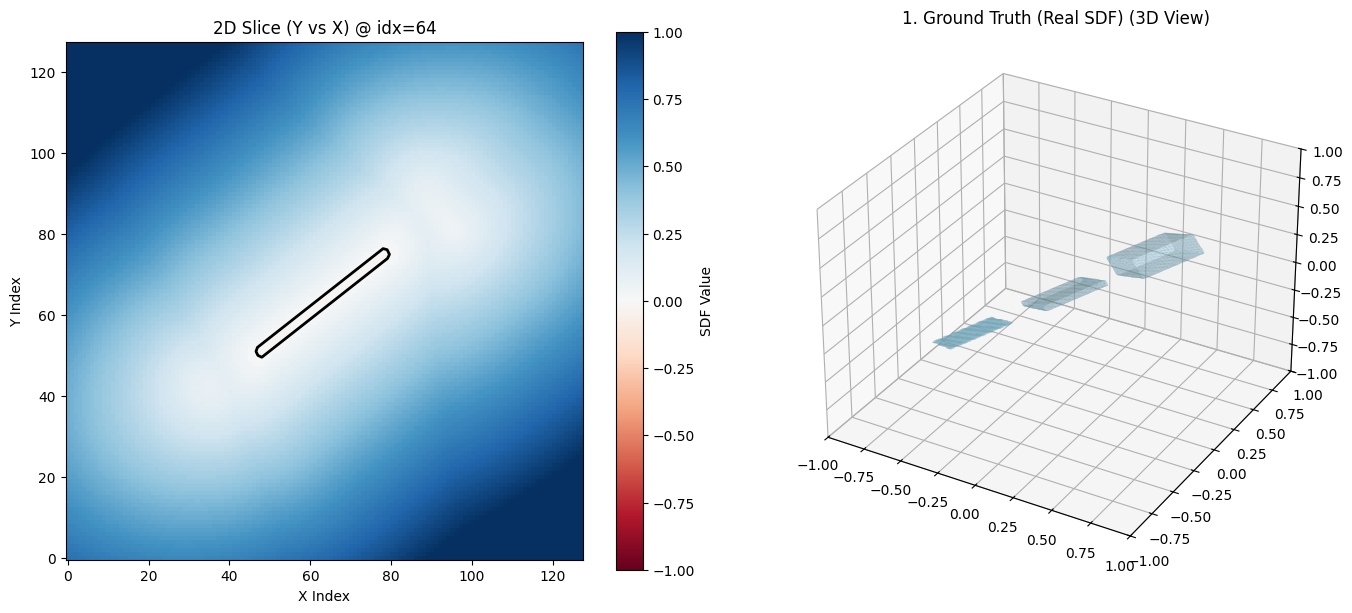

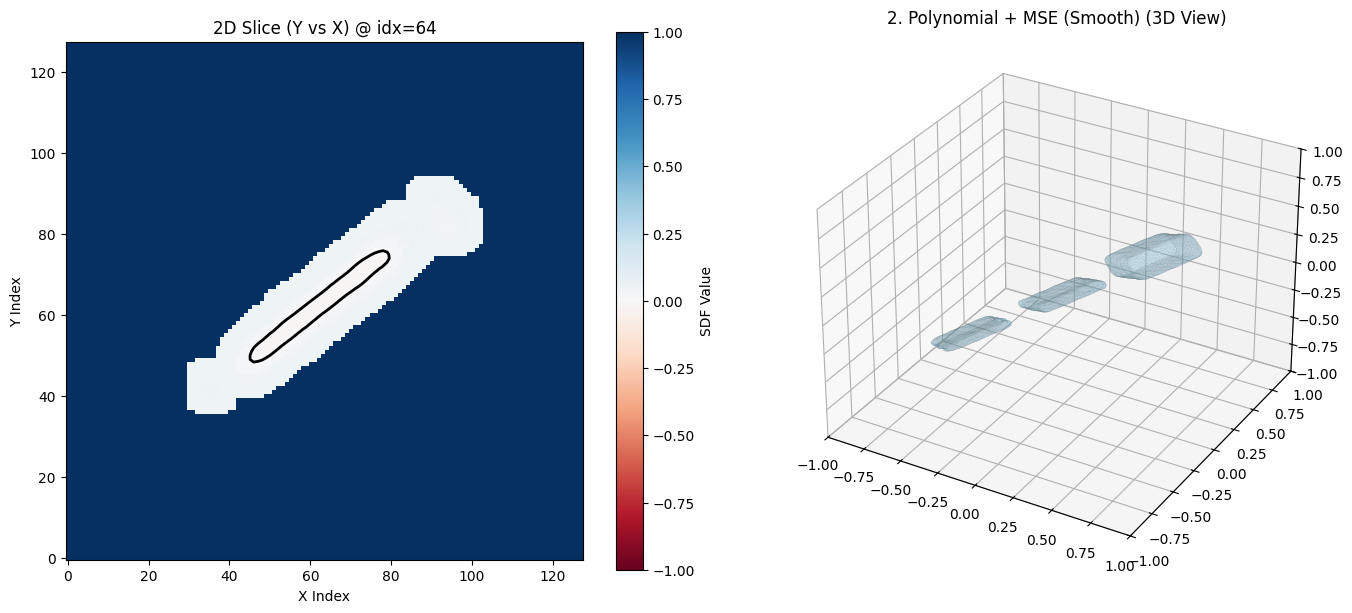

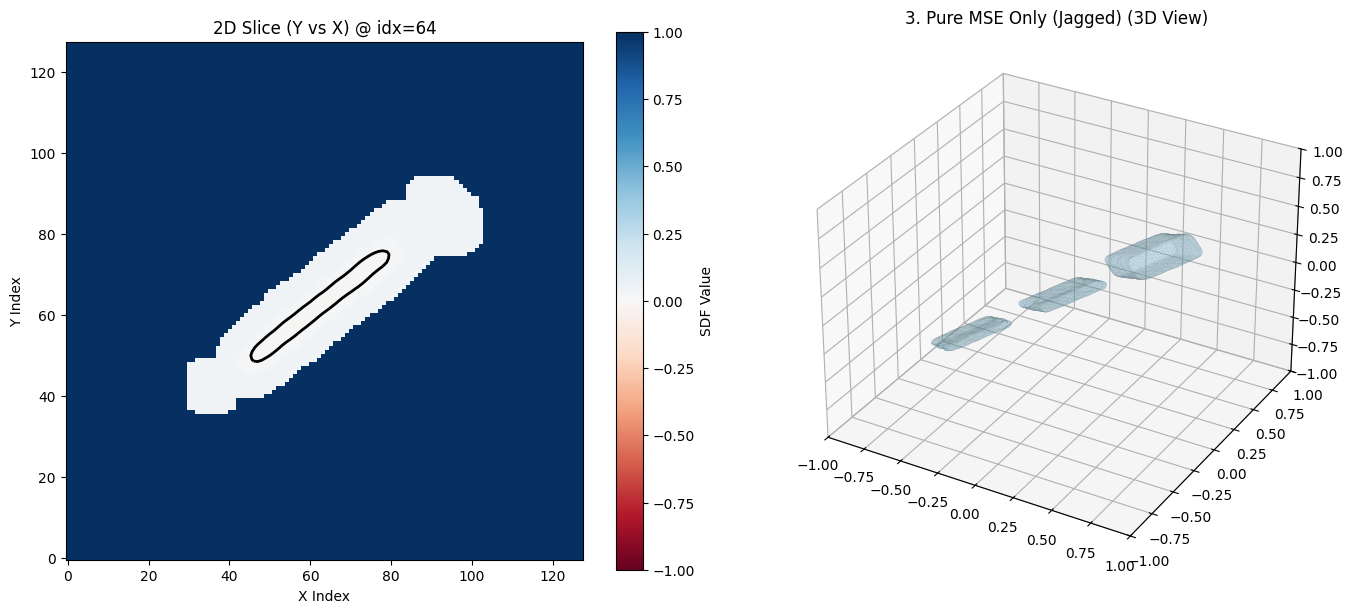

In [41]:
# 1. 평가용 데이터 로드 
# 🚨 핵심 변경: mc_grid.npy 대신 원본 파티클 좌표를 직접 불러옵니다!

save_dir = "./sample"
particles_np = np.load(os.path.join(save_dir, "particles_128.npy"))
particles_tensor = torch.tensor(particles_np, dtype=torch.float32, device=device)

sdf_grid_gt = np.load(os.path.join(save_dir, "sdf_grid_128.npy"))  # 정답지 (기본 해상도, 비교용)
# 추론 및 시각화를 위한 평가용 데이터 로드
m_c_grid_np = np.load(os.path.join(save_dir, "mc_grid_128.npy"))
m_c_grid_tensor = torch.tensor(m_c_grid_np, dtype=torch.float32)

print(">> 실험 1 추론")
reconstructor_poly = SDFReconstruction(dx=config.dx, ppc = 3.0, device=device)
reconstructor_poly.network = model_poly  # 학습된 모델 장착
pred_sdf_poly = reconstructor_poly.inference(m_c_grid_tensor, patch_size=8, batch_size=2048)

print(">> 실험 2 추론")
reconstructor_mse = SDFReconstruction(dx=config.dx, device=device)
reconstructor_mse.network = model_mse  # 두 번째로 학습된 모델 장착
pred_sdf_mse = reconstructor_mse.inference(m_c_grid_tensor, patch_size=8, batch_size=2048)


# ==========================================
# 📊 최종 결과 시각화 및 비교
# ==========================================
print("\n=== [Step 6] 결과물 시각화 (Ablation 비교) ===")

# 1. 정답지 (도넛 모양)
visualize_simulation(sdf_grid=sdf_grid_gt, domain_size=config.domain_size, title="1. Ground Truth (Real SDF)")

# 2. 논문 세팅 결과 (매끄러운 곡면)
visualize_simulation(sdf_grid=pred_sdf_poly.cpu().numpy(), domain_size=config.domain_size, title="2. Polynomial + MSE (Smooth)")

# 3. 정규화 끈 결과 (쭈글쭈글한 표면)
visualize_simulation(sdf_grid=pred_sdf_mse.cpu().numpy(), domain_size=config.domain_size, title="3. Pure MSE Only (Jagged)")

=== [Step 1] Ground Truth 시각화 ===


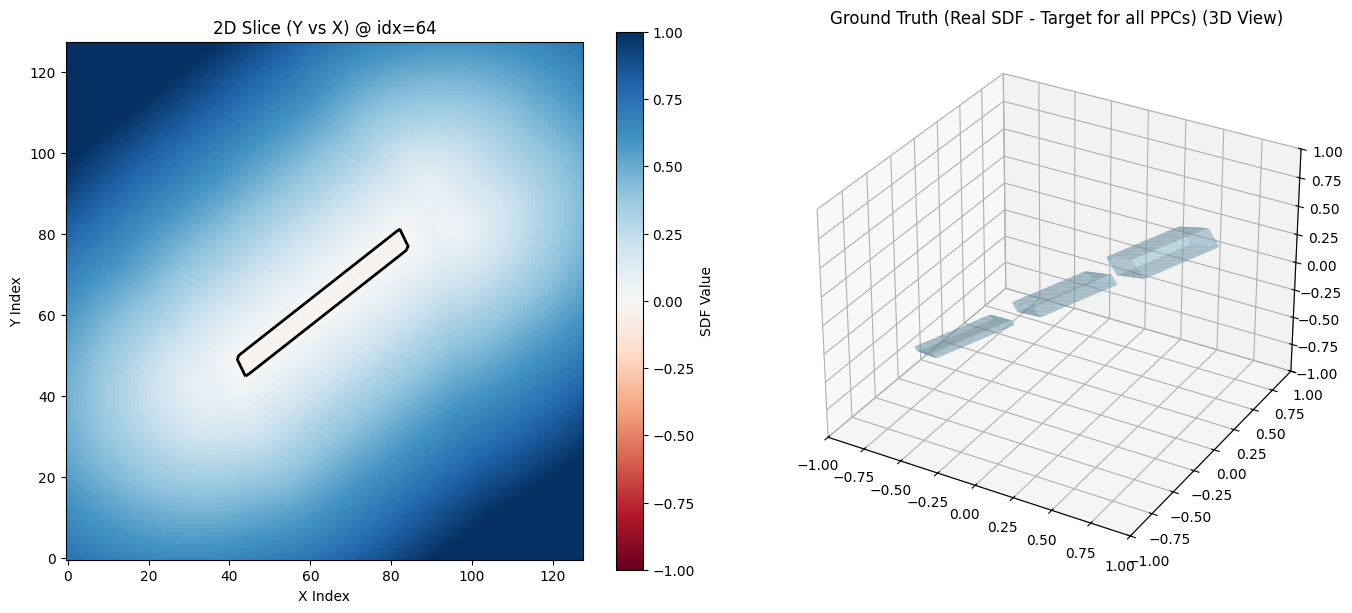


=== [Step 3] PPC별 추론 및 결과 비교 ===

=== [Step 2] 추론기 초기화 ===
self.R : 0.047244094488188976

----------------------------------------
🔍 [ PPC = 1 ] 데이터 평가 중...
   ✂️ [Pruning ON] 2097152개 중 152969개 노드 연산 (7.3%)
   📉 측정된 MSE 오차: 0.227655


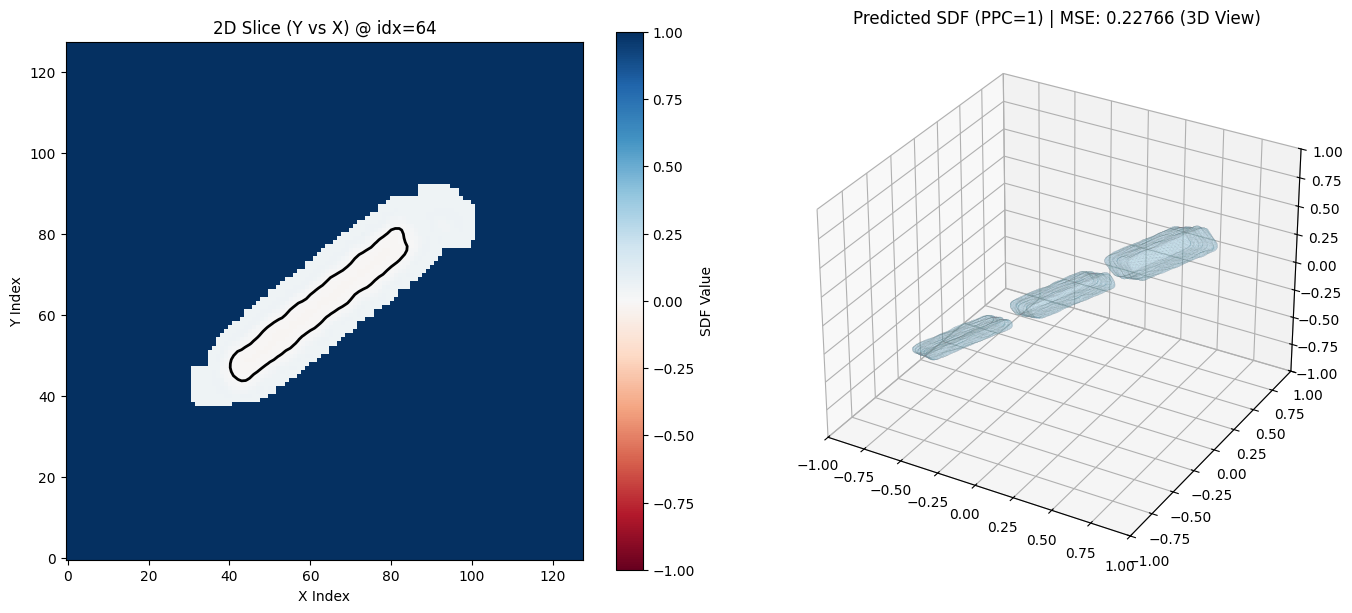


=== [Step 2] 추론기 초기화 ===
self.R : 0.047244094488188976

----------------------------------------
🔍 [ PPC = 2 ] 데이터 평가 중...
   ✂️ [Pruning ON] 2097152개 중 144712개 노드 연산 (6.9%)
   📉 측정된 MSE 오차: 0.230773


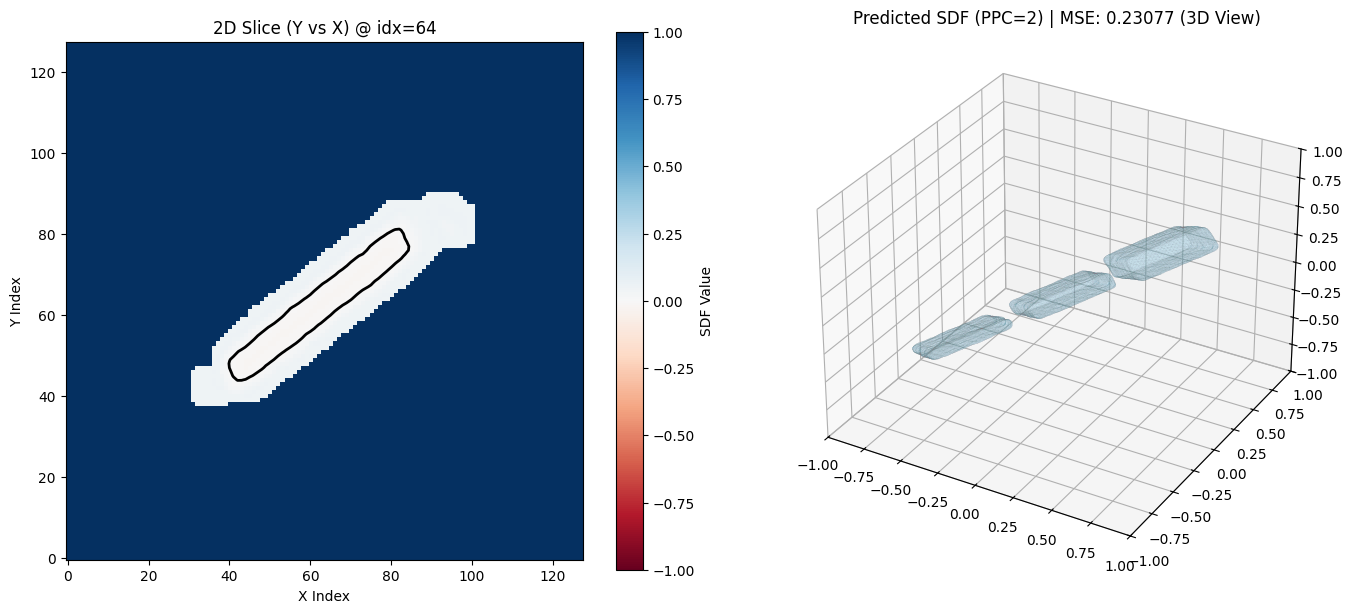


=== [Step 2] 추론기 초기화 ===
self.R : 0.047244094488188976

----------------------------------------
🔍 [ PPC = 3 ] 데이터 평가 중...
   ✂️ [Pruning ON] 2097152개 중 143441개 노드 연산 (6.8%)
   📉 측정된 MSE 오차: 0.231258


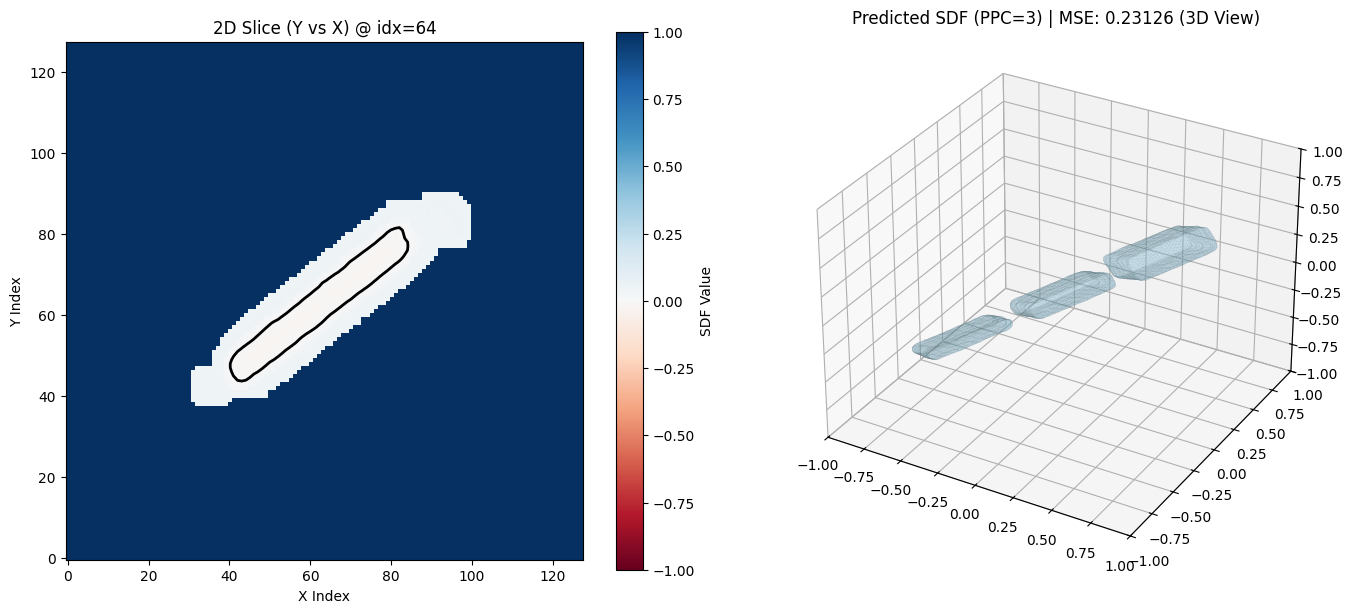


=== [Step 2] 추론기 초기화 ===
self.R : 0.047244094488188976

----------------------------------------
🔍 [ PPC = 4 ] 데이터 평가 중...
   ✂️ [Pruning ON] 2097152개 중 142325개 노드 연산 (6.8%)
   📉 측정된 MSE 오차: 0.231688


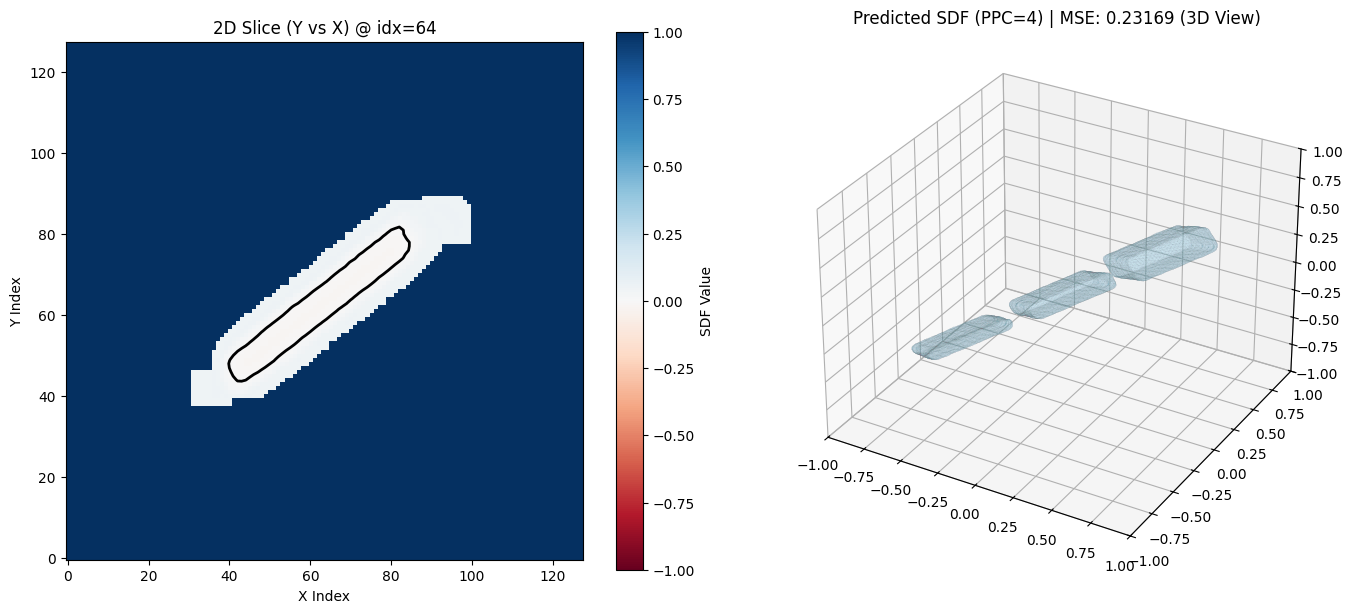


🎉 모든 PPC에 대한 추론 및 시각화가 완료되었습니다!


In [42]:
save_dir = "./dataset_ppc_test2"
ppc_list = [1, 2, 3, 4]
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ==========================================
# 1. 정답지(Ground Truth) 로드 및 시각화
# ==========================================
gt_path = os.path.join(save_dir, "sdf_grid_base.npy")
sdf_grid_gt = np.load(gt_path)

print("=== [Step 1] Ground Truth 시각화 ===")
visualize_simulation(
    sdf_grid=sdf_grid_gt, 
    domain_size=config.domain_size, 
    title="Ground Truth (Real SDF - Target for all PPCs)"
)
# ==========================================
# 3. PPC별 순회 추론 및 시각화 (Ablation Study)
# ==========================================
print("\n=== [Step 3] PPC별 추론 및 결과 비교 ===")

for ppc in ppc_list:
    print("\n=== [Step 2] 추론기 초기화 ===")
    reconstructor_poly = SDFReconstruction(dx=config.dx, device=device)
    reconstructor_poly.network = model_poly  # 학습이 완료된 모델 객체 연결

    print(f"\n{'-'*40}")
    print(f"🔍 [ PPC = {ppc} ] 데이터 평가 중...")
    
    # 1) 개별 m_c 특징맵 로드
    mc_filename = os.path.join(save_dir, f"mc_grid_ppc{ppc}.npy")
    if not os.path.exists(mc_filename):
        print(f"❌ 파일을 찾을 수 없습니다: {mc_filename}")
        continue
        
    m_c_grid_np = np.load(mc_filename)
    m_c_grid_tensor = torch.tensor(m_c_grid_np, dtype=torch.float32)
    
    # 2) 네트워크 추론 (Inference)
    pred_sdf_poly = reconstructor_poly.inference(
        m_c_grid_tensor, 
        patch_size=8, 
        batch_size=2048
    )
    pred_sdf_np = pred_sdf_poly.cpu().numpy()
    
    # 3) 정량적 평가 (MSE Error 계산)
    # 정답지와 예측지 간의 오차를 수치화하여 객관적 지표 획득
    mse_error = np.mean((sdf_grid_gt - pred_sdf_np) ** 2)
    print(f"   📉 측정된 MSE 오차: {mse_error:.6f}")
    
    # 4) 시각화 (도형 렌더링)
    visualize_simulation(
        sdf_grid=pred_sdf_np, 
        domain_size=config.domain_size, 
        title=f"Predicted SDF (PPC={ppc}) | MSE: {mse_error:.5f}"
    )

print("\n🎉 모든 PPC에 대한 추론 및 시각화가 완료되었습니다!")

=== [Step 1] Ground Truth 시각화 ===


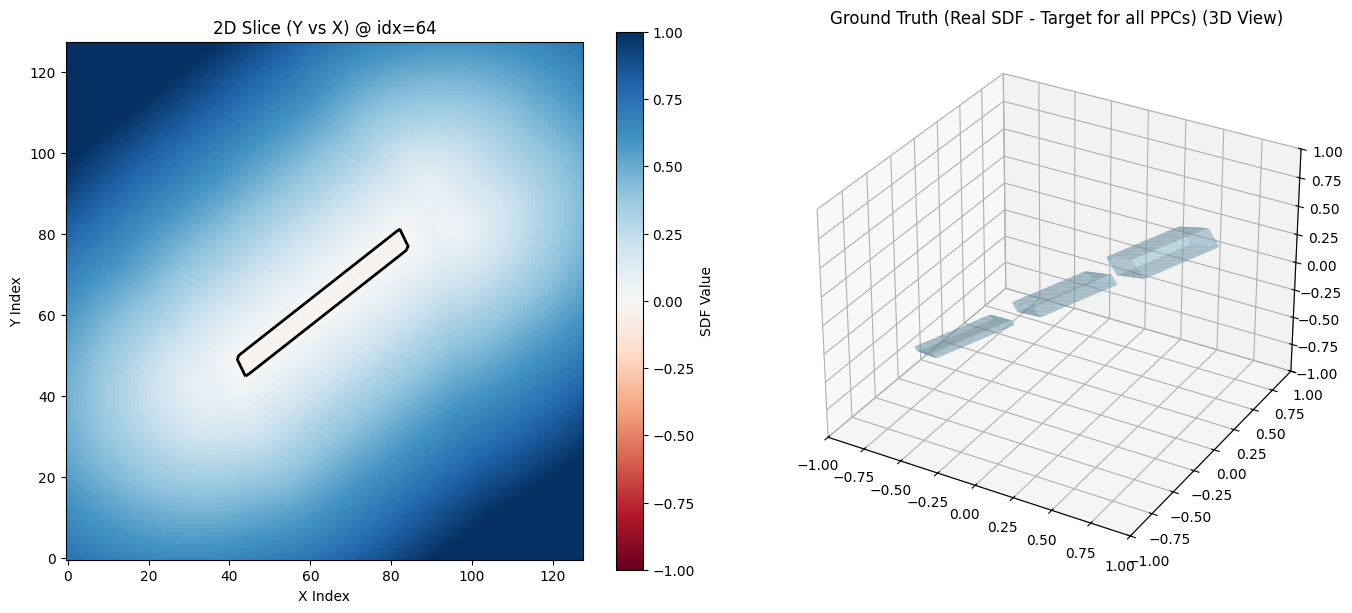


=== [Step 3] PPC별 추론 및 결과 비교 ===

=== [Step 2] 추론기 초기화 ===
self.R : 0.047244094488188976

----------------------------------------
🔍 [ PPC = 1 ] 데이터 평가 중...
🚀 [Staggered Reconstruction] 해상도(2배) 레벨셋 복원
 ⏳ 엇갈린 그리드 추론 중... 조합: a=0, b=0, c=0 (Offset: (0.0, 0.0, 0.0))
   ✂️ [Pruning ON] 2097152개 중 175430개 노드 연산 (8.4%)
 ⏳ 엇갈린 그리드 추론 중... 조합: a=0, b=0, c=1 (Offset: (0.0, 0.0, 0.007874015748031496))
   ✂️ [Pruning ON] 2097152개 중 175560개 노드 연산 (8.4%)
 ⏳ 엇갈린 그리드 추론 중... 조합: a=0, b=1, c=0 (Offset: (0.0, 0.007874015748031496, 0.0))
   ✂️ [Pruning ON] 2097152개 중 175261개 노드 연산 (8.4%)
 ⏳ 엇갈린 그리드 추론 중... 조합: a=0, b=1, c=1 (Offset: (0.0, 0.007874015748031496, 0.007874015748031496))
   ✂️ [Pruning ON] 2097152개 중 175302개 노드 연산 (8.4%)
 ⏳ 엇갈린 그리드 추론 중... 조합: a=1, b=0, c=0 (Offset: (0.007874015748031496, 0.0, 0.0))
   ✂️ [Pruning ON] 2097152개 중 175513개 노드 연산 (8.4%)
 ⏳ 엇갈린 그리드 추론 중... 조합: a=1, b=0, c=1 (Offset: (0.007874015748031496, 0.0, 0.007874015748031496))
   ✂️ [Pruning ON] 2097152개 중 175674개 노드 연산 (8

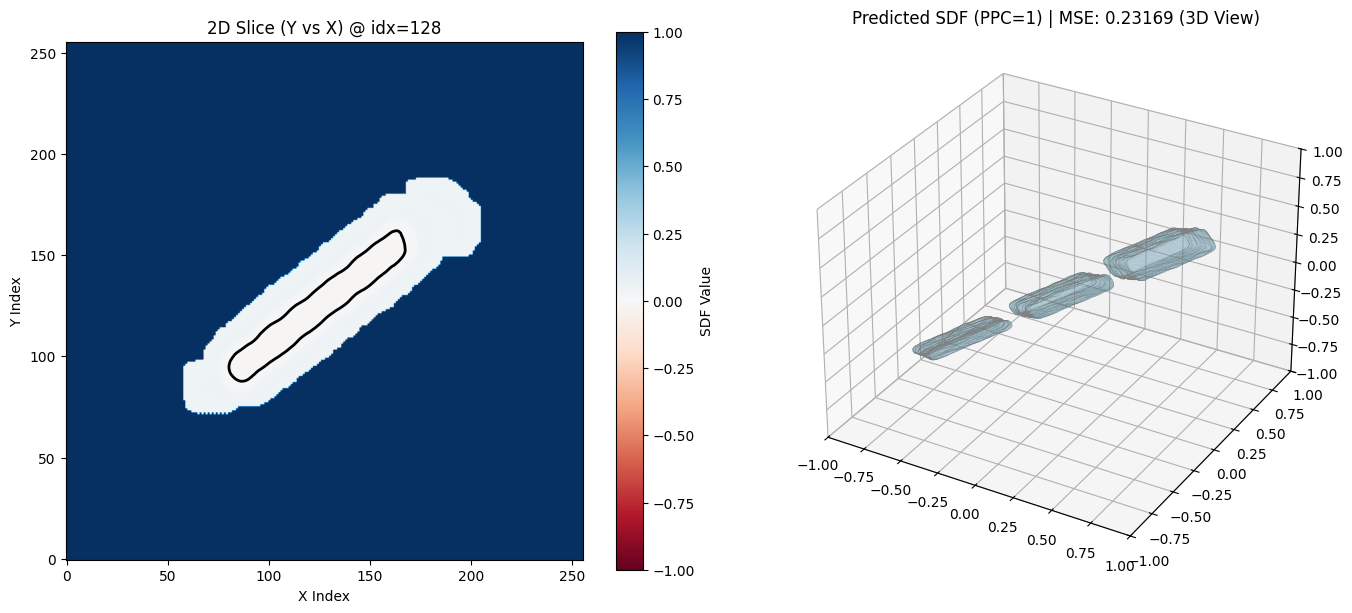


=== [Step 2] 추론기 초기화 ===
self.R : 0.04399528387376535

----------------------------------------
🔍 [ PPC = 2 ] 데이터 평가 중...
🚀 [Staggered Reconstruction] 해상도(2배) 레벨셋 복원
 ⏳ 엇갈린 그리드 추론 중... 조합: a=0, b=0, c=0 (Offset: (0.0, 0.0, 0.0))
   ✂️ [Pruning ON] 2097152개 중 174041개 노드 연산 (8.3%)
 ⏳ 엇갈린 그리드 추론 중... 조합: a=0, b=0, c=1 (Offset: (0.0, 0.0, 0.007874015748031496))
   ✂️ [Pruning ON] 2097152개 중 173913개 노드 연산 (8.3%)
 ⏳ 엇갈린 그리드 추론 중... 조합: a=0, b=1, c=0 (Offset: (0.0, 0.007874015748031496, 0.0))
   ✂️ [Pruning ON] 2097152개 중 173226개 노드 연산 (8.3%)
 ⏳ 엇갈린 그리드 추론 중... 조합: a=0, b=1, c=1 (Offset: (0.0, 0.007874015748031496, 0.007874015748031496))
   ✂️ [Pruning ON] 2097152개 중 173374개 노드 연산 (8.3%)
 ⏳ 엇갈린 그리드 추론 중... 조합: a=1, b=0, c=0 (Offset: (0.007874015748031496, 0.0, 0.0))
   ✂️ [Pruning ON] 2097152개 중 173233개 노드 연산 (8.3%)
 ⏳ 엇갈린 그리드 추론 중... 조합: a=1, b=0, c=1 (Offset: (0.007874015748031496, 0.0, 0.007874015748031496))
   ✂️ [Pruning ON] 2097152개 중 173360개 노드 연산 (8.3%)
 ⏳ 엇갈린 그리드 추론 중... 조합: a=1, b=

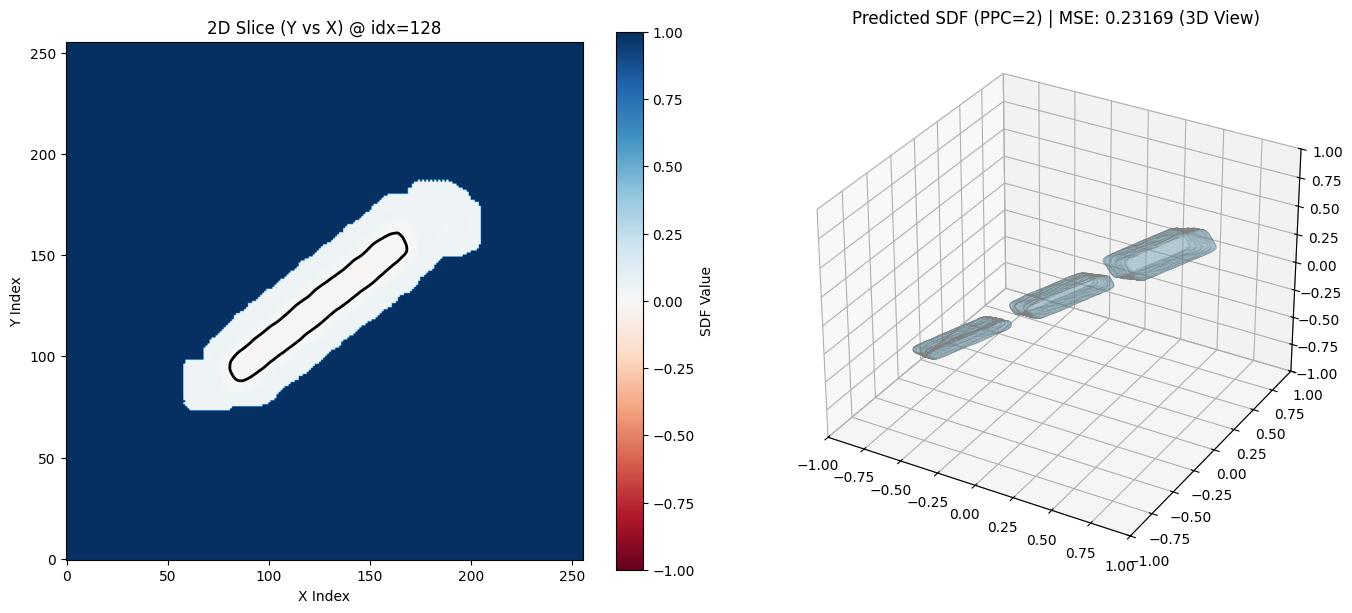


=== [Step 2] 추론기 초기화 ===
self.R : 0.04241513817875015

----------------------------------------
🔍 [ PPC = 3 ] 데이터 평가 중...
🚀 [Staggered Reconstruction] 해상도(2배) 레벨셋 복원
 ⏳ 엇갈린 그리드 추론 중... 조합: a=0, b=0, c=0 (Offset: (0.0, 0.0, 0.0))
   ✂️ [Pruning ON] 2097152개 중 173387개 노드 연산 (8.3%)
 ⏳ 엇갈린 그리드 추론 중... 조합: a=0, b=0, c=1 (Offset: (0.0, 0.0, 0.007874015748031496))
   ✂️ [Pruning ON] 2097152개 중 173338개 노드 연산 (8.3%)
 ⏳ 엇갈린 그리드 추론 중... 조합: a=0, b=1, c=0 (Offset: (0.0, 0.007874015748031496, 0.0))
   ✂️ [Pruning ON] 2097152개 중 172447개 노드 연산 (8.2%)
 ⏳ 엇갈린 그리드 추론 중... 조합: a=0, b=1, c=1 (Offset: (0.0, 0.007874015748031496, 0.007874015748031496))
   ✂️ [Pruning ON] 2097152개 중 172692개 노드 연산 (8.2%)
 ⏳ 엇갈린 그리드 추론 중... 조합: a=1, b=0, c=0 (Offset: (0.007874015748031496, 0.0, 0.0))
   ✂️ [Pruning ON] 2097152개 중 172216개 노드 연산 (8.2%)
 ⏳ 엇갈린 그리드 추론 중... 조합: a=1, b=0, c=1 (Offset: (0.007874015748031496, 0.0, 0.007874015748031496))
   ✂️ [Pruning ON] 2097152개 중 172551개 노드 연산 (8.2%)
 ⏳ 엇갈린 그리드 추론 중... 조합: a=1, b=

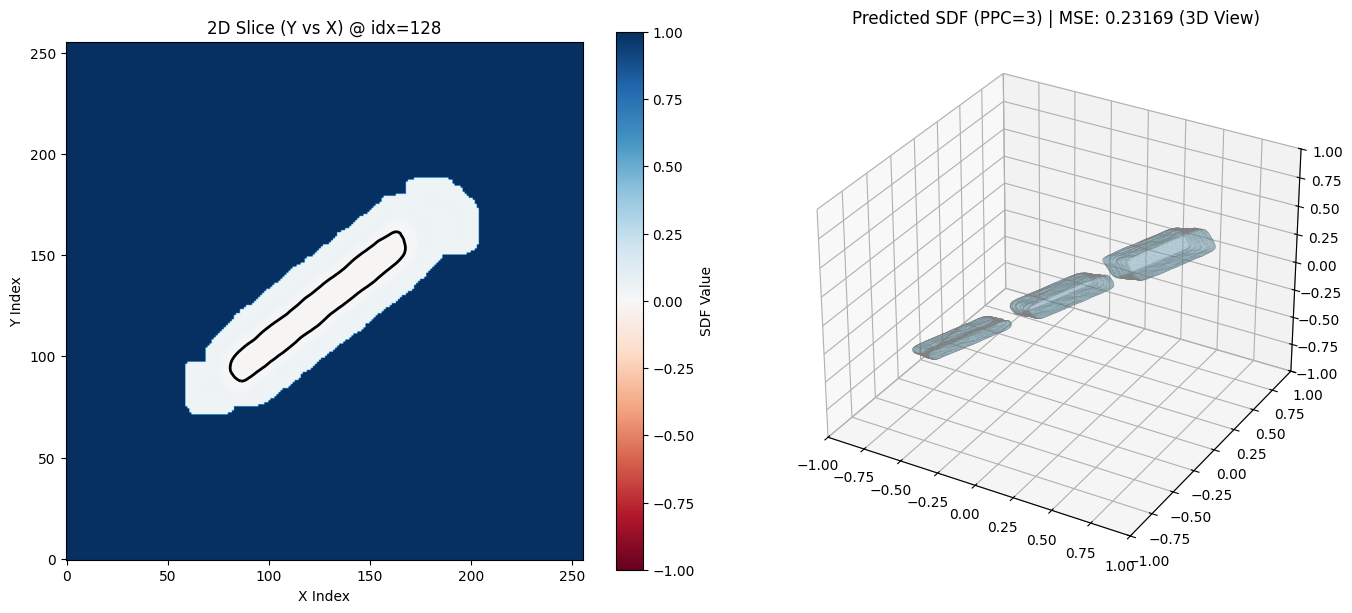


=== [Step 2] 추론기 초기화 ===
self.R : 0.041416701180274594

----------------------------------------
🔍 [ PPC = 4 ] 데이터 평가 중...
🚀 [Staggered Reconstruction] 해상도(2배) 레벨셋 복원
 ⏳ 엇갈린 그리드 추론 중... 조합: a=0, b=0, c=0 (Offset: (0.0, 0.0, 0.0))
   ✂️ [Pruning ON] 2097152개 중 172580개 노드 연산 (8.2%)
 ⏳ 엇갈린 그리드 추론 중... 조합: a=0, b=0, c=1 (Offset: (0.0, 0.0, 0.007874015748031496))
   ✂️ [Pruning ON] 2097152개 중 172614개 노드 연산 (8.2%)
 ⏳ 엇갈린 그리드 추론 중... 조합: a=0, b=1, c=0 (Offset: (0.0, 0.007874015748031496, 0.0))
   ✂️ [Pruning ON] 2097152개 중 171817개 노드 연산 (8.2%)
 ⏳ 엇갈린 그리드 추론 중... 조합: a=0, b=1, c=1 (Offset: (0.0, 0.007874015748031496, 0.007874015748031496))
   ✂️ [Pruning ON] 2097152개 중 171924개 노드 연산 (8.2%)
 ⏳ 엇갈린 그리드 추론 중... 조합: a=1, b=0, c=0 (Offset: (0.007874015748031496, 0.0, 0.0))
   ✂️ [Pruning ON] 2097152개 중 171399개 노드 연산 (8.2%)
 ⏳ 엇갈린 그리드 추론 중... 조합: a=1, b=0, c=1 (Offset: (0.007874015748031496, 0.0, 0.007874015748031496))
   ✂️ [Pruning ON] 2097152개 중 171568개 노드 연산 (8.2%)
 ⏳ 엇갈린 그리드 추론 중... 조합: a=1, b

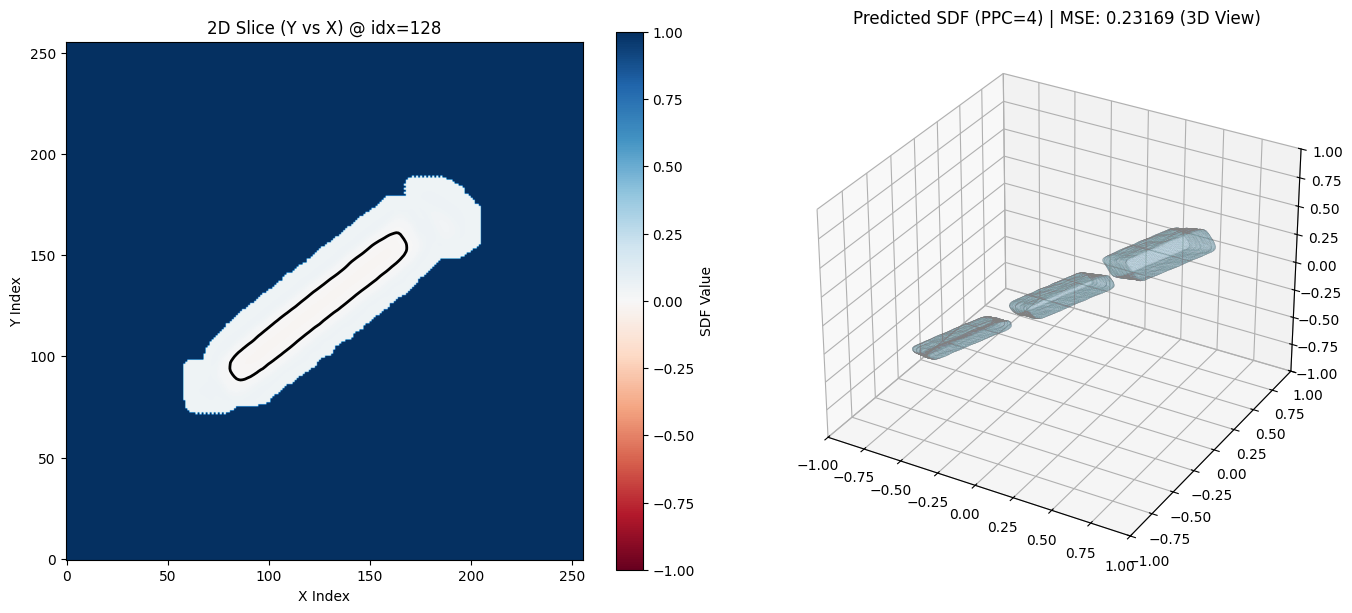


🎉 모든 PPC에 대한 추론 및 시각화가 완료되었습니다!


In [43]:
import torch
import numpy as np
import os

# (config, SDFReconstruction, visualize_simulation, model_poly 등은 이미 로드/정의되었다고 가정합니다)

save_dir = "./dataset_ppc_test2"
ppc_list = [1, 2, 3, 4]
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ==========================================
# 1. 정답지(Ground Truth) 로드 및 시각화
# ==========================================
gt_path = os.path.join(save_dir, "sdf_grid_base.npy")
sdf_grid_gt = np.load(gt_path)

print("=== [Step 1] Ground Truth 시각화 ===")
visualize_simulation(
    sdf_grid=sdf_grid_gt, 
    domain_size=config.domain_size, 
    title="Ground Truth (Real SDF - Target for all PPCs)"
)
# ==========================================
# 3. PPC별 순회 추론 및 시각화 (Ablation Study)
# ==========================================
print("\n=== [Step 3] PPC별 추론 및 결과 비교 ===")

for ppc in ppc_list:
    print("\n=== [Step 2] 추론기 초기화 ===")
    reconstructor_poly = SDFReconstruction(dx=config.dx, ppc = ppc, device=device)
    reconstructor_poly.network = model_poly  # 학습이 완료된 모델 객체 연결

    print(f"\n{'-'*40}")
    print(f"🔍 [ PPC = {ppc} ] 데이터 평가 중...")
    
    # 1) mc_grid 대신 원본 파티클 좌표(particles_ppc.npy) 직접 로드
    particles_filename = os.path.join(save_dir, f"particles_ppc{ppc}.npy")
    if not os.path.exists(particles_filename):
        print(f"❌ 파일을 찾을 수 없습니다: {particles_filename}")
        continue
        
    particles_np = np.load(particles_filename)
    particles_tensor = torch.tensor(particles_np, dtype=torch.float32, device=device)
        
    m_c_grid_np = np.load(mc_filename)
    m_c_grid_tensor = torch.tensor(m_c_grid_np, dtype=torch.float32)
    
    # 2) 네트워크 추론 (Inference)
    pred_sdf_poly_high_res = reconstructor_poly.staggered_inference(
        particles_tensor, patch_size=8, batch_size=2048
    )
    pred_sdf_np = pred_sdf_poly_high_res.cpu().numpy()
    
    # 4) 시각화 (도형 렌더링)
    visualize_simulation(
        sdf_grid=pred_sdf_np, 
        domain_size=config.domain_size, 
        title=f"Predicted SDF (PPC={ppc}) | MSE: {mse_error:.5f}"
    )

print("\n🎉 모든 PPC에 대한 추론 및 시각화가 완료되었습니다!")


>> 🎯 특정 테스트 데이터(Shape 100) 추론 시작
>> Poly 모델(정규화 ON)로 Shape 100 추론 중...
   ✂️ [Pruning ON] 2146689개 중 819426개 노드 연산 (38.2%)
>> MSE 모델(정규화 OFF)로 Shape 100 추론 중...
   ✂️ [Pruning ON] 2146689개 중 819426개 노드 연산 (38.2%)

=== [Step 7] Shape 100 결과물 시각화 (Unseen Data Test) ===


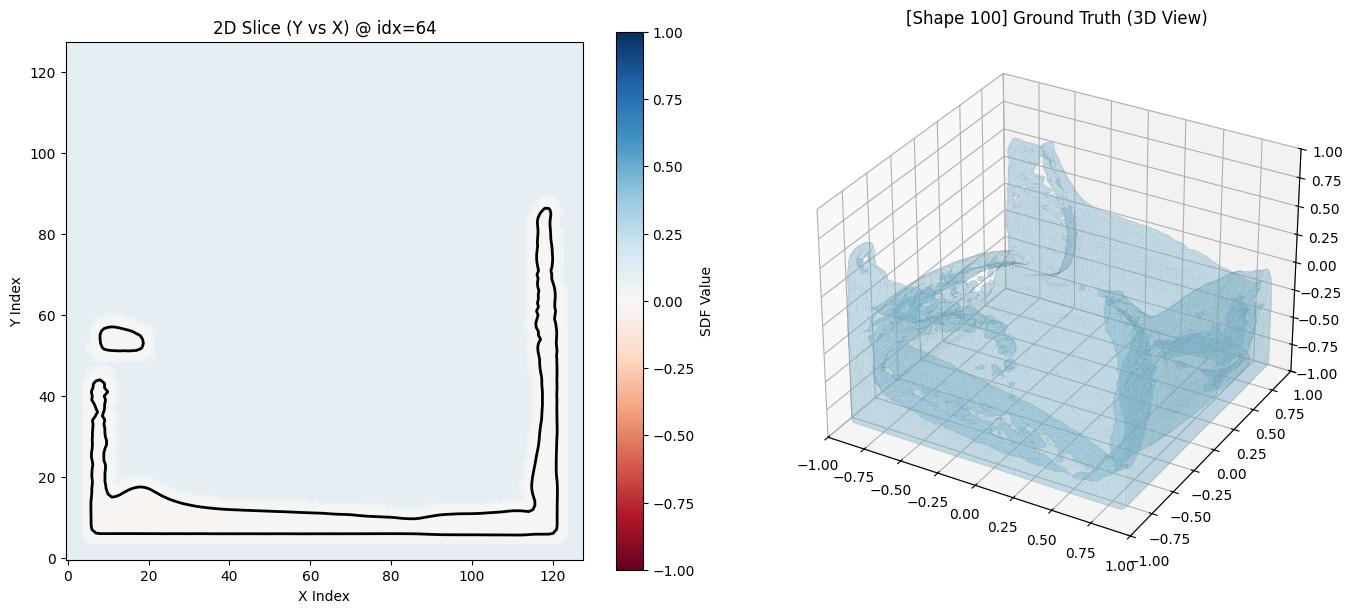

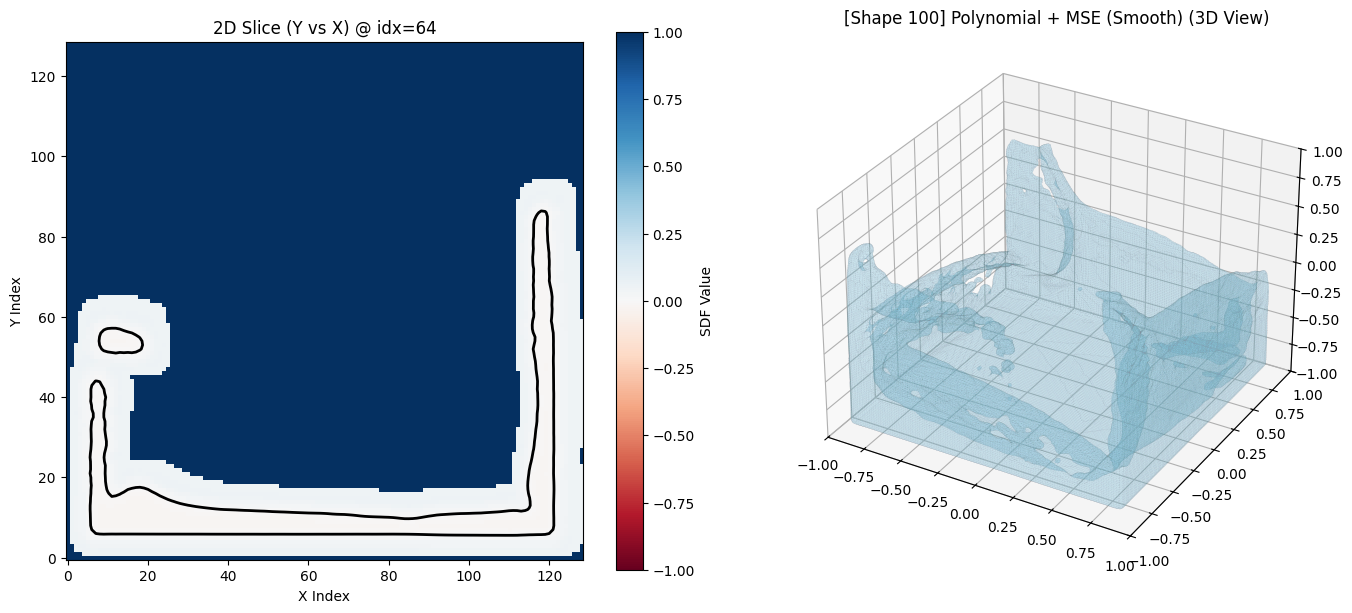

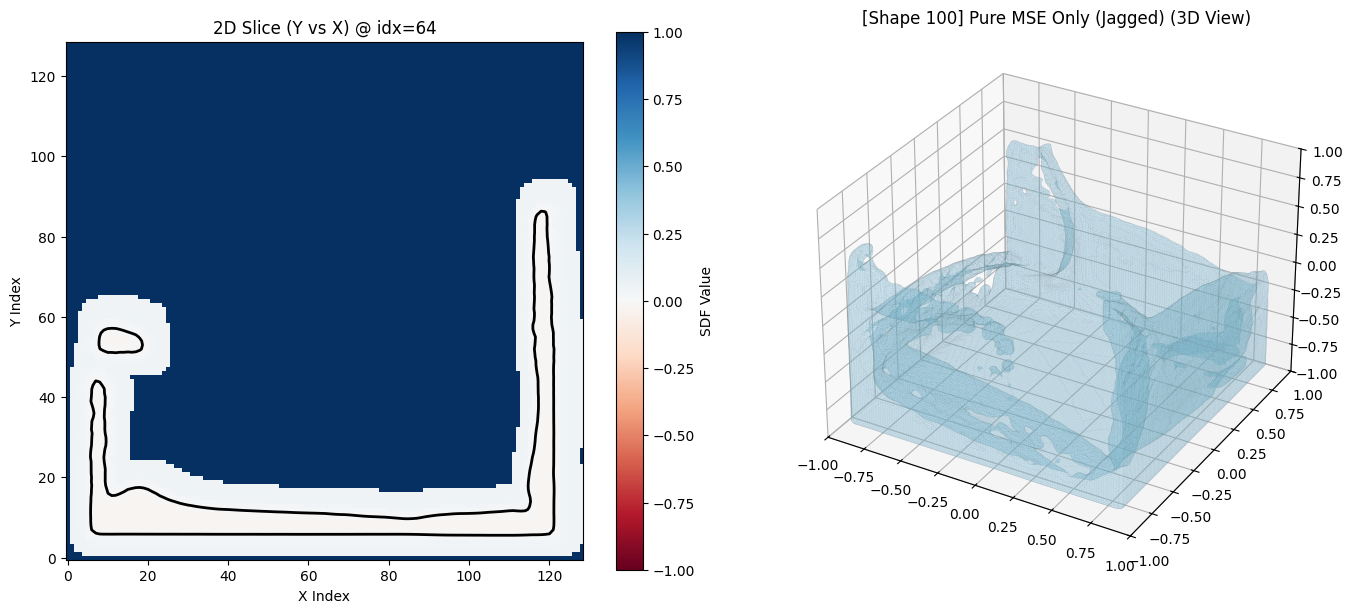

In [44]:
# ==========================================
# 🎯 [추가 실험] 특정 데이터 추론 및 비교
# ==========================================
# 🚨 여기서 원하는 데이터의 인덱스 번호만 바꾸면 끝입니다! (예: 1, 9, 10)
target_idx = 100

# 0을 채워서 자동으로 3자리 문자열로 만듭니다. (예: 1 -> "001", 15 -> "015")
shape_name = f"{target_idx:03d}" 

print("\n" + "="*55)
print(f">> 🎯 특정 테스트 데이터(Shape {shape_name}) 추론 시작")
print("="*55)

# 1. 지정된 타겟 & 특징 그리드 로드 (전처리 완전 생략!)
# 파일 경로가 자동으로 세팅됩니다.
sdf_path = f"dataset6/sdf_grid_{shape_name}.npy"
mc_path = f"dataset6/mc_grid_{shape_name}.npy"

target_sdf = np.load(sdf_path)
m_c_grid_np = np.load(mc_path)

# 텐서 변환
m_c_grid_tensor = torch.tensor(m_c_grid_np, dtype=torch.float32)

# 2. [Poly 모드] 이미 학습된 Poly 모델로 초고속 추론
print(f">> Poly 모델(정규화 ON)로 Shape {shape_name} 추론 중...")
pred_sdf_poly = reconstructor_poly.inference(m_c_grid_tensor, patch_size=8, batch_size=2048)

# 3. [MSE 모드] 이미 학습된 MSE 모델로 초고속 추론
print(f">> MSE 모델(정규화 OFF)로 Shape {shape_name} 추론 중...")
pred_sdf_mse = reconstructor_mse.inference(m_c_grid_tensor, patch_size=8, batch_size=2048)

# ==========================================
# 📊 결과 시각화 및 비교
# ==========================================
print(f"\n=== [Step 7] Shape {shape_name} 결과물 시각화 (Unseen Data Test) ===")

# 1. 정답지 (진짜 모습)
visualize_simulation(
    sdf_grid=target_sdf, 
    domain_size=config.domain_size, 
    title=f"[Shape {shape_name}] Ground Truth"
)

# 2. 논문 세팅 결과 (정규화가 들어간 매끄러운 예측 결과)
visualize_simulation(
    sdf_grid=pred_sdf_poly.cpu().numpy(), 
    domain_size=config.domain_size, 
    title=f"[Shape {shape_name}] Polynomial + MSE (Smooth)"
)

# 3. 정규화 끈 결과 (정규화가 없을 때의 쭈글쭈글한 예측 결과)
visualize_simulation(
    sdf_grid=pred_sdf_mse.cpu().numpy(), 
    domain_size=config.domain_size, 
    title=f"[Shape {shape_name}] Pure MSE Only (Jagged)"
)


>> 🎯 특정 테스트 데이터(Shape 100) 고해상도(2배) 추론 시작
>> Poly 모델(정규화 ON)로 Shape 100 고해상도 뻥튀기 중...
🚀 [Staggered Reconstruction] 해상도(2배) 레벨셋 복원
 ⏳ 엇갈린 그리드 추론 중... 조합: a=0, b=0, c=0 (Offset: (0.0, 0.0, 0.0))
   ✂️ [Pruning ON] 2097152개 중 742887개 노드 연산 (35.4%)
 ⏳ 엇갈린 그리드 추론 중... 조합: a=0, b=0, c=1 (Offset: (0.0, 0.0, 0.007874015748031496))
   ✂️ [Pruning ON] 2097152개 중 749292개 노드 연산 (35.7%)
 ⏳ 엇갈린 그리드 추론 중... 조합: a=0, b=1, c=0 (Offset: (0.0, 0.007874015748031496, 0.0))
   ✂️ [Pruning ON] 2097152개 중 750538개 노드 연산 (35.8%)
 ⏳ 엇갈린 그리드 추론 중... 조합: a=0, b=1, c=1 (Offset: (0.0, 0.007874015748031496, 0.007874015748031496))
   ✂️ [Pruning ON] 2097152개 중 756672개 노드 연산 (36.1%)
 ⏳ 엇갈린 그리드 추론 중... 조합: a=1, b=0, c=0 (Offset: (0.007874015748031496, 0.0, 0.0))
   ✂️ [Pruning ON] 2097152개 중 749433개 노드 연산 (35.7%)
 ⏳ 엇갈린 그리드 추론 중... 조합: a=1, b=0, c=1 (Offset: (0.007874015748031496, 0.0, 0.007874015748031496))
   ✂️ [Pruning ON] 2097152개 중 755571개 노드 연산 (36.0%)
 ⏳ 엇갈린 그리드 추론 중... 조합: a=1, b=1, c=0 (Offset: (0.00787401574

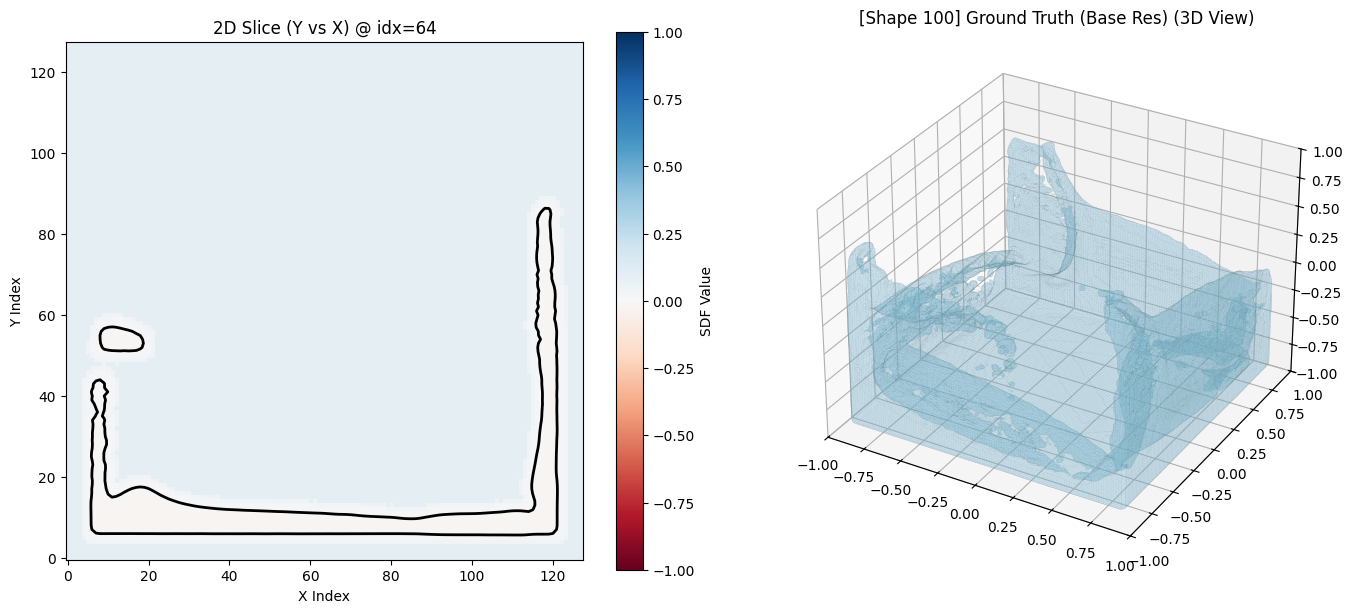

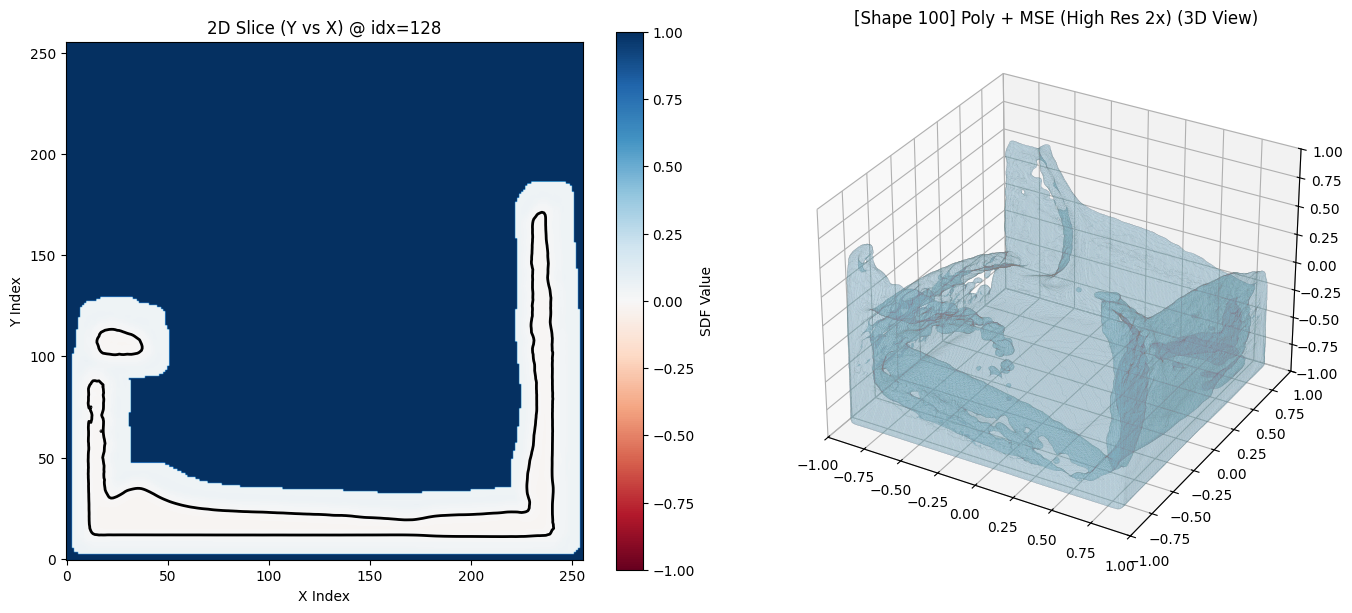

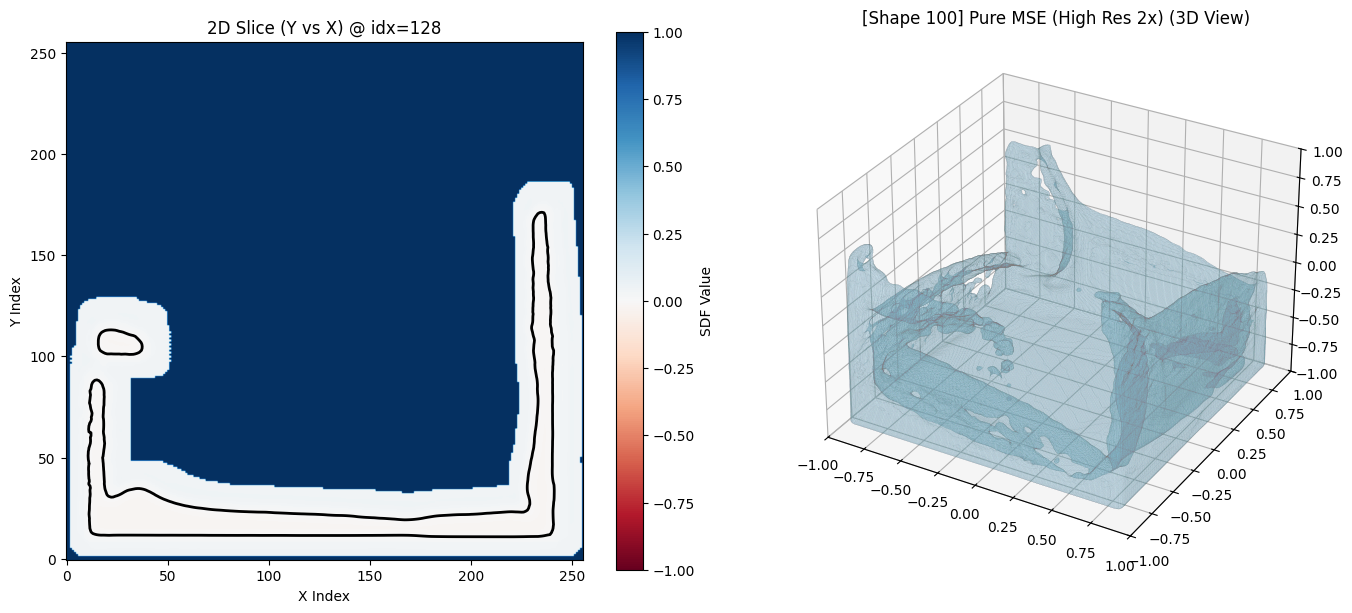

In [45]:
# ==========================================
# 🎯 특정 데이터 고해상도(Staggered) 추론 및 비교
# ==========================================
target_idx = 100

# 0을 채워서 자동으로 3자리 문자열로 만듭니다. (예: 1 -> "001", 15 -> "015")
shape_name = f"{target_idx:03d}" 

print("\n" + "="*55)
print(f">> 🎯 특정 테스트 데이터(Shape {shape_name}) 고해상도(2배) 추론 시작")
print("="*55)

# 1. 원본 파티클 데이터 & 정답 타겟 그리드 로드
sdf_path = f"dataset6/sdf_grid_{shape_name}.npy"
particles_path = f"dataset6/particles_{shape_name}.npy"

target_sdf = np.load(sdf_path)          # (N, N, N) 기본 해상도 정답지
particles_np = np.load(particles_path)  # 원본 파티클 좌표

# 파티클을 텐서로 변환하여 GPU로 전송
particles_tensor = torch.tensor(particles_np, dtype=torch.float32, device=device)

# 2. [Poly 모드] 엇갈린 그리드(Staggered) 다중 추론 
print(f">> Poly 모델(정규화 ON)로 Shape {shape_name} 고해상도 뻥튀기 중...")
start_time = time.time()
pred_sdf_poly = reconstructor_poly.staggered_inference(
    particles_tensor, patch_size=8, batch_size=2048
)
print(f"   -> ⏱️ 소요 시간: {time.time() - start_time:.1f}초")

# 3. [MSE 모드] 엇갈린 그리드(Staggered) 다중 추론
print(f">> MSE 모델(정규화 OFF)로 Shape {shape_name} 고해상도 뻥튀기 중...")
start_time = time.time()
pred_sdf_mse = reconstructor_mse.staggered_inference(
    particles_tensor, patch_size=8, batch_size=2048
)
print(f"   -> ⏱️ 소요 시간: {time.time() - start_time:.1f}초")

# ==========================================
# 📊 결과 시각화 및 비교
# ==========================================
print(f"\n=== [Step 7] Shape {shape_name} 고해상도 결과물 시각화 ===")
print("💡 참고: Ground Truth는 기본 해상도(N)이며, 예측 결과는 2배 해상도(2N)입니다.")

# 1. 정답지 (기본 해상도)
visualize_simulation(
    sdf_grid=target_sdf, 
    domain_size=config.domain_size, 
    title=f"[Shape {shape_name}] Ground Truth (Base Res)"
)

# 2. 논문 세팅 결과 (2배 해상도 + 정규화로 매우 매끄러움)
visualize_simulation(
    sdf_grid=pred_sdf_poly.cpu().numpy(), 
    domain_size=config.domain_size, 
    title=f"[Shape {shape_name}] Poly + MSE (High Res 2x)"
)

# 3. 정규화 끈 결과 (2배 해상도지만 표면이 울퉁불퉁할 수 있음)
visualize_simulation(
    sdf_grid=pred_sdf_mse.cpu().numpy(), 
    domain_size=config.domain_size, 
    title=f"[Shape {shape_name}] Pure MSE (High Res 2x)"
)


>> 🎯 외부 파티클 데이터(frame_094.txt) 고해상도(2배) 추론 시작
📄 파티클 파일 로드 중: ./sample\frame_094.txt
🔍 변환 전 파티클 범위: Min 0.004 ~ Max 0.994
🚀 변환 후 파티클 범위: Min -0.595 ~ Max 0.592 (그리드 최적화 완료!)
✅ 로드 완료! 정상 파티클: 358,770개 (건너뛴 줄: 0개)
📊 공간 분석: 전체 16,777,216개 격자 중 유체 내부(음수) 격자는 111,969개 (0.67%) 입니다.
   -> ⏱️ 변환 소요 시간: 0.3초
self.R : 0.047244094488188976

>> Poly 모델(정규화 ON)로 고해상도 추론
🚀 [Staggered Reconstruction] 해상도(2배) 레벨셋 복원
 ⏳ 엇갈린 그리드 추론 중... 조합: a=0, b=0, c=0 (Offset: (0.0, 0.0, 0.0))
   ✂️ [Pruning ON] 2097152개 중 128710개 노드 연산 (6.1%)
 ⏳ 엇갈린 그리드 추론 중... 조합: a=0, b=0, c=1 (Offset: (0.0, 0.0, 0.007874015748031496))
   ✂️ [Pruning ON] 2097152개 중 129284개 노드 연산 (6.2%)
 ⏳ 엇갈린 그리드 추론 중... 조합: a=0, b=1, c=0 (Offset: (0.0, 0.007874015748031496, 0.0))
   ✂️ [Pruning ON] 2097152개 중 131212개 노드 연산 (6.3%)
 ⏳ 엇갈린 그리드 추론 중... 조합: a=0, b=1, c=1 (Offset: (0.0, 0.007874015748031496, 0.007874015748031496))
   ✂️ [Pruning ON] 2097152개 중 131834개 노드 연산 (6.3%)
 ⏳ 엇갈린 그리드 추론 중... 조합: a=1, b=0, c=0 (Offset: (0.007874015748031496, 0.0

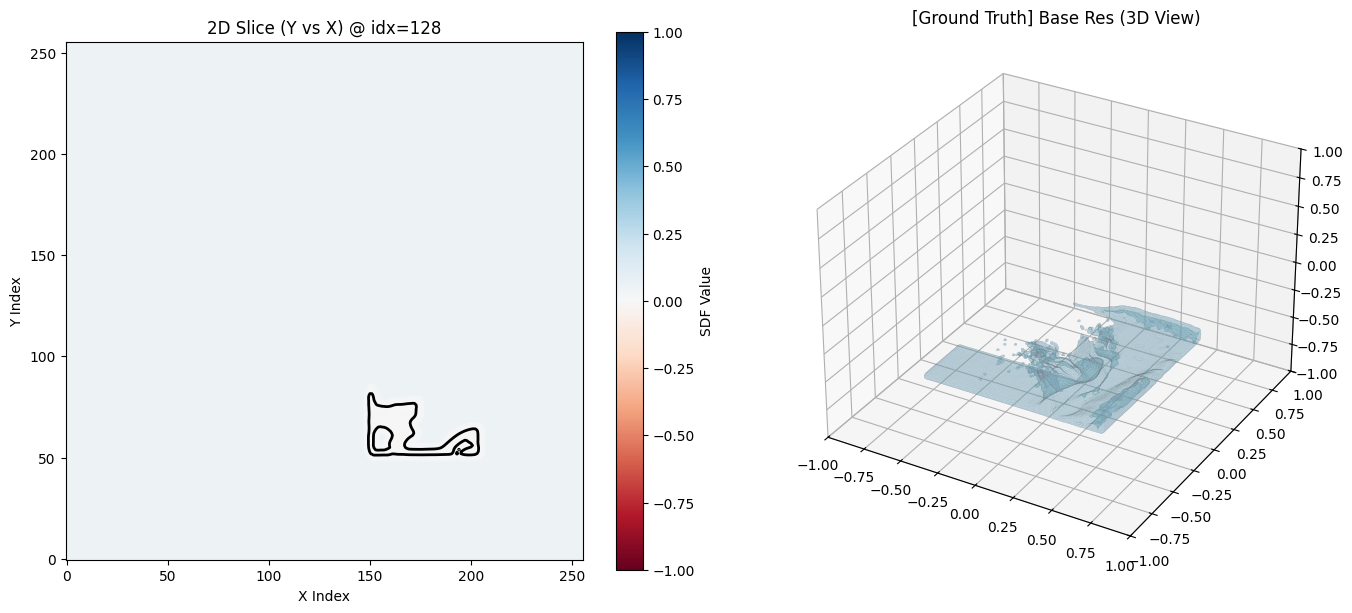

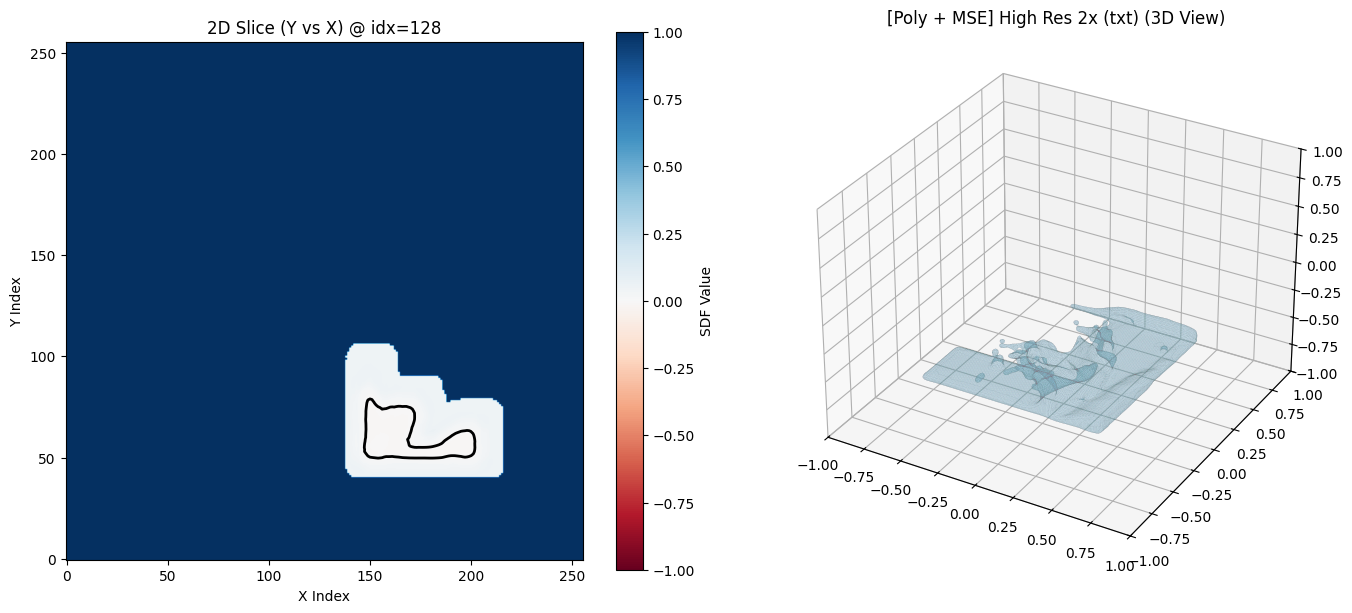

In [46]:

# 만약 정답지(GT) SDF가 있다면 경로를 적고, 없다면 None으로 두세요.
gt_sdf_path = None # 예: "dataset5/sdf_grid_001.npy"
txt_particle_path = "frame_094.txt"
print("\n" + "="*55)
print(f">> 🎯 외부 파티클 데이터({txt_particle_path}) 고해상도(2배) 추론 시작")
print("="*55)

# 1. 텍스트 파티클 데이터 텐서로 로드
save_dir = "./sample"
particles_tensor = load_particles_from_txt(os.path.join(save_dir, txt_particle_path), device=device)

# 정답지 로드 (있는 경우에만)
target_sdf = None
if gt_sdf_path and os.path.exists(gt_sdf_path):
    target_sdf = np.load(gt_sdf_path)
    print("📊 정답지(Ground Truth) SDF를 로드했습니다.")
else:
    # print("💡 정답지(Ground Truth) 없이 모델 예측만 수행합니다.")
    # GPU 텐서일 수 있으므로 CPU로 내린 뒤 Numpy 배열로 변환
    particles_np = particles_tensor.cpu().numpy()

    # 2. 고해상도(2배) 해상도 계산
    # 기존 추론 코드에서 patch_size=8 및 Staggered 방식을 통해 2배 뻥튀기 하므로, GT도 2배로 맞춥니다.
    high_res = config.resolution * 2  

    # 3. Taichi 커널을 이용해 파티클 -> SDF 변환
    # (클래스 이름이 TaichiFluidSolver가 아니라면 알맞게 수정해주세요)
    start_time = time.time()
    
    target_sdf = TaichiFluidSolver.convert_particles_to_sdf(
        particles_np=particles_np,
        res=high_res,
        domain_size=config.domain_size,
        radius_ratio = 1.25  # 0.75~1.25 세팅
    )
    print(f"   -> ⏱️ 변환 소요 시간: {time.time() - start_time:.1f}초")


reconstructor_poly = SDFReconstruction(dx=config.dx, ppc = 1.0, device=device)
reconstructor_poly.network = model_poly  # 첫 번째로 학습된 모델 장착

# 2. [Poly] 엇갈린 그리드(Staggered) 다중 추론 
print("\n>> Poly 모델(정규화 ON)로 고해상도 추론")
start_time = time.time()
pred_sdf_poly_high_res = reconstructor_poly.staggered_inference(
    particles_tensor, patch_size=8, batch_size=2048
)
print(f"   -> ⏱️ 소요 시간: {time.time() - start_time:.1f}초")

# ==========================================
# 📊 결과 시각화 및 비교
# ==========================================
print(f"\n=== [Step 3] 예측 결과물 시각화 ===")

# 1. 정답지 (존재할 때만 렌더링)
if target_sdf is not None:
    visualize_simulation(
        sdf_grid=target_sdf, 
        domain_size=config.domain_size, 
        title="[Ground Truth] Base Res"
    )

# 2. 논문 세팅 결과 (2배 해상도 + 정규화로 매우 매끄러움)
visualize_simulation(
    sdf_grid=pred_sdf_poly_high_res.cpu().numpy(), 
    domain_size=config.domain_size, 
    title="[Poly + MSE] High Res 2x (txt)"
)

## 4. SDF 값 시각화 (최종 결과)

In [47]:
from modules.visualizer import visualize_npy
from modules.visualizer import save_mesh_as_obj # 시각화용
from modules.visualizer import visualize_simulation
from modules.visualizer import view_obj_interactive, view_obj_and_particles_interactive

#### 4.2 obj로 저장 & 시각화

In [ ]:
output_dir = "output"
save_mesh_as_obj(target_sdf, filename=os.path.join(output_dir, "gt_high.obj"))
save_mesh_as_obj(pred_sdf_poly.cpu().numpy(), filename=os.path.join(output_dir, "pred_sdf_poly.obj"))
save_mesh_as_obj(pred_sdf_mse.cpu().numpy(), filename=os.path.join(output_dir, "pred_sdf_mse.obj"))

✅ 메쉬 저장 완료: output\gt_high.obj (Vertices: 66291)
✅ 메쉬 저장 완료: output\pred_sdf_poly.obj (Vertices: 59496)


NameError: name 'pred_sdf_mse_high_res' is not defined

4.2.1 visualize with particle

In [ ]:
# 1. 파일에서 넘파이 배열 읽어오기
# particles_np = np.load("frame_001.npy")
save_dir = "./sample"
particles_np = load_particles_from_txt(os.path.join(save_dir, "frame_094.txt"))
# 🚨 변경된 부분: x, y, z에 각각 0. 5 오프셋 추가
particles_np += 0.5

# 2. 뷰어에 메쉬와 파티클 배열 함께 전달하기
save_dir = "./output"
view_obj_and_particles_interactive(os.path.join(save_dir, "gt_high.obj"), particles_np, 128, 1.0)

📄 파티클 파일 로드 중: frame_094.txt
🔍 변환 전 파티클 범위: Min 0.004 ~ Max 0.994
🚀 변환 후 파티클 범위: Min -0.892 ~ Max 0.889 (그리드 최적화 완료!)
✅ 로드 완료! 정상 파티클: 358,770개 (건너뛴 줄: 0개)
🖥️ 3D 뷰어 실행 중 (실시간 좌표 변환 적용): gt_high.obj ...
✅ 파티클 358,770개 정렬 완료.
🔍 메쉬 범위 확인: -0.40 ~ 1.40


4.2.2 visualize without particle

In [ ]:
# OBJ 파일 인터랙티브 뷰어
save_dir = "./output"
view_obj_interactive(os.path.join(save_dir, "gt_high.obj"))

✅ 메쉬 저장 완료: gt_high.obj (Vertices: 66291)
🖥️ 3D 뷰어 실행 중: gt_high.obj ...
✅ 뷰어 종료됨.


In [ ]:
# OBJ 파일 인터랙티브 뷰어
save_dir = "./output"
view_obj_interactive(os.path.join(save_dir, "pred_sdf_mse.obj"))

🖥️ 3D 뷰어 실행 중: pred_sdf_mse.obj ...
✅ 뷰어 종료됨.


In [ ]:
# OBJ 파일 인터랙티브 뷰어
save_dir = "./output"
view_obj_interactive(os.path.join(save_dir, "pred_sdf_poly.obj"))

🖥️ 3D 뷰어 실행 중: pred_sdf_poly.obj ...
✅ 뷰어 종료됨.
